# 01_saccades_visualization

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import random
import copy

import subprocess

from urllib.request import urlopen

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from torchvision import datasets, transforms

from pathlib import Path

from torchvision.models import ResNet50_Weights
from torchvision.transforms import functional as FF

from s3c.models.foveated_vit import FoveatedMultiViT, build_foveated_pos_embed
from s3c.models.heads import ShiftPredictor, FovealSetTransformer
from s3c.models.student_teacher import StudentWithYPredictor
from s3c.data.datasets import FoveatedUpletDataset, make_dataloader, collate_uplet
from s3c.data.transforms import ShiftZoomUplet, FoveatedPyramidTransform
from s3c.utils.viz import foveate_mosaic, compute_saliency_grid
from s3c.models.heads import IterativeSeedTransformerwithQuery, ABMILLabelPredictor, WhereIterativeSeedTransformer, AttentionPooling, ABMILPosPredictor 

import timm

from PIL import Image

from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [20]:
# Monter le dossier distant
local = False #True #
if not local:
    #mount_point = os.path.expanduser("~/imagenet_mount")
    mount_point = os.path.expanduser("~/data/Imagenet_full")

    try:
        os.makedirs(mount_point, exist_ok=True)
        subprocess.run(["sshfs", "dauce.e@brain-lid-004:data/Imagenet_full", mount_point, "-o", "reconnect"], check=True)
    except:
        pass

    train_dir = os.path.join(mount_point, "train")
    val_dir = os.path.join(mount_point, "val")
else:
    train_dir = "/media/dauce/T7/data/Imagenet_full/train" #"~/data/Imagenet_full/train"   # Imagenet Validation set
    val_dir = "/media/dauce/T7/data/Imagenet_full/val" #"~/data/Imagenet_full/val"   # Imagenet Validation set

fusermount3: failed to access mountpoint /home/dauce/data/Imagenet_full: Permission denied


In [21]:
# ImageFolder sans transform — le Dataset s'en charge entièrement
train_dataset_raw = datasets.ImageFolder(train_dir, transform=None)
val_dataset_raw   = datasets.ImageFolder(val_dir,   transform=None)

uplet_tf = ShiftZoomUplet(zoom=1.5, std=0.3, n_uplet=5)

batch_size=1
num_workers = 12

zoom = 1.5

std = 0.5 / zoom

n_sac = 5

train_dataset = FoveatedUpletDataset(
    base_folder=train_dataset_raw, # ImageFolder
    zoom=zoom,
    std=std,
    start_center=False, 
    n_uplet=n_sac,
)
val_dataset = FoveatedUpletDataset(
    base_folder=val_dataset_raw, # ImageFolder
    zoom=zoom,
    std=std,
    start_center=False, 
    n_uplet=n_sac,
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = batch_size,
    shuffle     = True,
    num_workers = num_workers,
    collate_fn  = collate_uplet,
    pin_memory  = True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = batch_size,
    shuffle     = False,
    num_workers = num_workers,
    collate_fn  = collate_uplet,
    pin_memory  = True,
)

## Visualization

In [22]:
classes = ResNet50_Weights.DEFAULT.meta['categories']
classes

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'European fire salamander',
 'common newt',
 'eft',
 'spotted salamander',
 'axolotl',
 'bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead',
 'leatherback turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'common iguana',
 'American chameleon',
 'whiptail',
 'agama',
 'frilled lizard',
 'alligator lizard',
 'Gila monster',
 'green lizard',
 'African chameleon',
 'Komodo dragon',
 'African crocodile',
 'American alligator',
 'triceratops',
 'thunder snake',
 'ringneck snake',
 'hognose snake',
 'green snake',
 'king snake',
 'garter snake',
 'water snake',
 'vine snake',
 'night snake',
 'boa constrictor',
 'rock python',
 'Indian cobr

In [23]:
def denormalize(tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """tensor : (C, H, W) ou (B, C, H, W)"""
    m = torch.tensor(mean).view(-1, 1, 1)
    s = torch.tensor(std).view(-1, 1, 1)
    return (tensor.cpu().float() * s + m).clamp(0, 1)

In [24]:
def visualize_saccades(dataset, idx=0, n_views=5, zoom=1.5, std=0.3, seed=42):
    """
    Visualise une séquence de saccades sur une image du dataset.

    Gauche  : image originale (512×512) + trajectoire des saccades
    Droite  : n_views vues fovéales reconstruites via foveate_mosaic
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    # ── 1. Image brute (avant transform) ────────────────────────────────
    # On accède au dataset de base pour avoir la PIL originale
    img_pil, label = dataset.base[idx]
    #pre    = dataset.pre                         # Resize + CenterCrop
    #img_pil = pre(img_pil)                       # PIL 512×512
    img_np  = np.array(img_pil)                  # (512, 512, 3)  uint8

    # ── 2. Générer les saccades avec les mêmes paramètres ───────────────
    sz = ShiftZoomUplet(zoom=zoom, std=std, n_uplet=n_views)
    views = sz(img_pil)   # liste de (pil_shifted, sx, sy, zoom)

    # Coordonnées des points de fixation dans l'image 512×512
    # sx, sy ∈ [-1, 1] → pixels dans l'image zoomée recadrée
    # Le centre de fixation dans l'image originale est :
    #   cx_px = 512/2 * (1 + sx/2)  (même formule que shift_zoom)
    W, H   = img_pil.size   # 512, 512
    fix_pts = []
    for _, sx, sy, _ in views:
        #zoomed_ref = min(int(W * zoom), int(H * zoom))
        #cx = zoomed_ref / 2 * (1 + sx / 2)
        #cy = zoomed_ref / 2 * (1 + sy / 2)
        w_zoomed   = int(W * zoom)
        h_zoomed   = int(H * zoom)
        zoomed_ref = min(w_zoomed, h_zoomed)   # petit côté zoomé — référence du shift
        cx = w_zoomed / 2 + zoomed_ref * sx / 2 #zoomed_ref / 2 * (1 + x / 2)   # ∈ [zoomed_ref/4, 3*zoomed_ref/4]
        sy_prim = sy # !! (no) sign inversion
        cy = h_zoomed / 2 + zoomed_ref * sy_prim / 2 #zoomed_ref / 2 * (1 + y / 2)
        # ramener dans le repère image originale (avant zoom)
        cx_orig = cx / zoom
        cy_orig = cy / zoom
        fix_pts.append((cx_orig, cy_orig))

    # ── 3. Construire les mosaïques fovéales ─────────────────────────────
    #fov_tf     = dataset.fov          # FoveatedPyramidTransform
    #to_tensor  = dataset.to_tensor
    #normalize  = dataset.normalize

    fov_tf = dataset.fovea_transform
    post_process = dataset.post_process

    mosaics = []
    for pil_shifted, sx, sy, z in views:
        mosaic = fov_tf(pil_shifted)         # PIL 128×128
        mosaic = post_process(mosaic)
        mosaics.append(mosaic)

    mosaics = torch.stack(mosaics).unsqueeze(0)   # (1, V, 3, 128, 128)
    # foveate_mosaic attend (B, C, H, W) — on boucle sur les vues
    fov_imgs = []
    for v in range(n_views):
        mosaic_v  = mosaics[0, v].unsqueeze(0)    # (1, 3, 128, 128)
        mosaic_d  = denormalize(mosaic_v[0]).unsqueeze(0)  # dénorm avant foveate
        fov_out   = foveate_mosaic(mosaic_d)       # (1, 3, 512, 512)
        fov_np    = fov_out[0].permute(1, 2, 0).numpy()   # (512,512,3)
        fov_np    = np.clip(fov_np, 0, 1)
        fov_imgs.append(fov_np)

    # ── 4. Figure ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(4 + 3 * n_views, 4))
    # grille : 1 colonne pour l'original + n_views colonnes pour les vues
    gs  = fig.add_gridspec(1, 1 + n_views, wspace=0.05,
                           width_ratios=[2] + [1] * n_views)

    # ── Panneau gauche : image originale + saccades ──────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img_np)

    colors = plt.cm.plasma(np.linspace(0.1, 0.9, n_views))

    xs_plot = [pt[0] for pt in fix_pts]
    ys_plot = [pt[1] for pt in fix_pts]

    # trajectoire
    ax0.plot(xs_plot, ys_plot,
             color='white', linewidth=1.2, alpha=0.7, zorder=2)

    # points de fixation numérotés
    for i, (px, py) in enumerate(fix_pts):
        ax0.scatter(px, py, color=colors[i], s=80, zorder=3,
                    edgecolors='white', linewidths=0.8)
        ax0.text(px + 8, py - 8, str(i + 1),
                 color=colors[i], fontsize=8, fontweight='bold',
                 zorder=4)

    # croix au centre
    ax0.axhline(H / 2, color='white', linewidth=0.5, alpha=0.3)
    ax0.axvline(W / 2, color='white', linewidth=0.5, alpha=0.3)

    ax0.set_title(f"Image originale\n(classe {classes[label]} ({label}))", fontsize=9)
    #ax0.axis('off')

    # légende colorbar saccades
    legend_handles = [
        mpatches.Patch(color=colors[i], label=f"saccade {i+1}  "
                       f"sx={views[i][1]:+.2f} sy={views[i][2]:+.2f}")
        for i in range(n_views)
    ]
    ax0.legend(handles=legend_handles, fontsize=6.5,
               loc='lower left', framealpha=0.6)

    # ── Panneaux droits : vues fovéales ──────────────────────────────────
    for v in range(n_views):
        ax = fig.add_subplot(gs[0, 1 + v])
        ax.imshow(fov_imgs[v])
        ax.set_title(f"Vue {v+1}\nsx={views[v][1]:+.2f}\nsy={views[v][2]:+.2f}",
                     fontsize=7.5, color=colors[v])
        # cadre coloré selon la saccade
        for spine in ax.spines.values():
            spine.set_edgecolor(colors[v])
            spine.set_linewidth(2.5)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle("Séquence de saccades fovéales", fontsize=11, y=1.02)
    plt.savefig("saccades_visualization.png", dpi=150,
                bbox_inches='tight', facecolor='black')
    plt.show()
    return fig

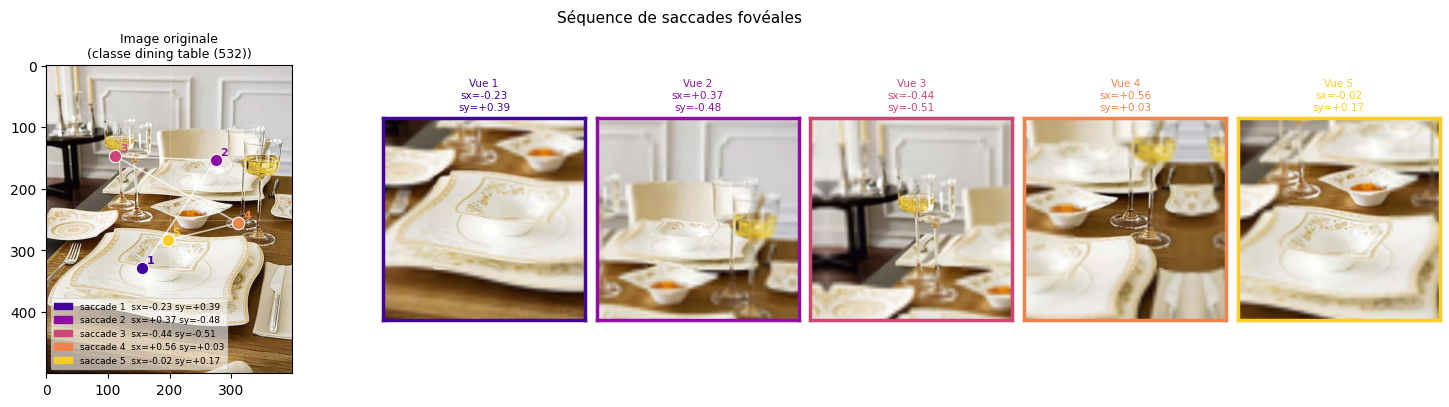

26640


In [25]:
#from s3c.utils.viz import denormalize, visualize_saccades
seed = 31
np.random.seed(seed)
idx = np.random.randint(50000) 
# ── Appel ─────────────────────────────────────────────────────────────────
fig = visualize_saccades(
    dataset  = val_dataset,   # FoveatedUpletDataset
    idx      = idx, #23443, #15442,            # index dans le val set
    n_views  = 5,
    zoom     = 1.5,
    std      = 0.3,
    seed     = 44,
)

print(idx)

2537  : alligator

14100 : chat noir  (282)
14148 : chat gris

17530 : bouquetins

41091 : pont en fer

31402 : paquebot

26640 : dining table

## Teacher / Student

In [26]:
model_dir = "../checkpoints/checkpoints_EMA_Xattn_260416"

epoch_teacher = 20



model_name = "vit_base_patch8_224.dino"
model_orig = timm.create_model(model_name, pretrained=True)

#model.head = nn.Identity()  # Supprimer la tête existante
model_orig.patch_embed.strict_img_size = False
norm_ref = copy.deepcopy(model_orig.norm)

#state_dict = torch.load("dino_v3_tiny_pretrained.pth")
#model.load_state_dict(state_dict, strict=False)

build_foveated_pos_embed(model_orig,
                        base_img_size=224,
                        patch_size=8,
                        mosaic_sub_patch_grid=8,   # 8 patches par sous-image (64px/8)
                        scales=(1.0, 0.5, 0.25, 0.125))

model = FoveatedMultiViT(model_orig, norm=False)

In [27]:
teacher_model = timm.create_model(model_name, pretrained=True)
teacher_model.patch_embed.strict_img_size = False
teacher_model.norm = nn.Identity() # no final layernorm!!


build_foveated_pos_embed(teacher_model,
                        base_img_size=224,
                        patch_size=8,
                        mosaic_sub_patch_grid=8,   # 8 patches par sous-image (64px/8)
                        scales=(1.0, 0.5, 0.25, 0.125))


checkpoint_path = os.path.join(model_dir, f"checkpoint_epoch{epoch_teacher}.pt")  # exemple
checkpoint = torch.load(checkpoint_path, map_location="cpu")
# Vérifie les clés disponibles
print("Clés du checkpoint :", checkpoint.keys())
# --- Récupération des poids du teacher ---
if "teacher" not in checkpoint:
    raise KeyError(f"Aucune clé 'teacher' trouvée dans {checkpoint_path}")

state_dict = checkpoint["teacher"]

# --- Chargement dans le modèle ---
missing, unexpected = teacher_model.load_state_dict(state_dict, strict=False)

print("➡️ Poids chargés (teacher).")
print("❗ Paramètres manquants :", missing)
print("⚠️ Paramètres inattendus :", unexpected)

teacher_model.to(device)
teacher_model.eval()


Clés du checkpoint : dict_keys(['epoch', 'batch', 'student', 'teacher', 'mlp', 'history'])
➡️ Poids chargés (teacher).
❗ Paramètres manquants : []
⚠️ Paramètres inattendus : []


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(8, 8), stride=(8, 8))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
  

In [28]:
checkpoint_path = os.path.join(model_dir, f"checkpoint_epoch{epoch_teacher}.pt")  # exemple
checkpoint = torch.load(checkpoint_path, map_location="cpu")
# Vérifie les clés disponibles
print("Clés du checkpoint :", checkpoint.keys())
# --- Récupération des poids du teacher ---
if "teacher" not in checkpoint:
    raise KeyError(f"Aucune clé 'teacher' trouvée dans {checkpoint_path}")

state_dict = checkpoint["teacher"]


# --- Chargement dans le modèle ---
missing, unexpected = model.model.load_state_dict(state_dict, strict=False)

print("➡️ Poids chargés (teacher).")
print("❗ Paramètres manquants :", missing)
print("⚠️ Paramètres inattendus :", unexpected)

model.model.norm = nn.Identity() # pas de normalisation en sortie !
model.eval()
model.to(device)

Clés du checkpoint : dict_keys(['epoch', 'batch', 'student', 'teacher', 'mlp', 'history'])
➡️ Poids chargés (teacher).
❗ Paramètres manquants : ['norm.weight', 'norm.bias']
⚠️ Paramètres inattendus : []


FoveatedMultiViT(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(8, 8), stride=(8, 8))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (a

In [29]:
dino_student_y = StudentWithYPredictor(model_orig).to(device)

if "student" not in checkpoint:
    raise KeyError(f"Aucune clé 'student' trouvée dans {checkpoint_path}")

state_dict = checkpoint["student"]
# --- Chargement dans le modèle ---
missing, unexpected = dino_student_y.load_state_dict(state_dict, strict=False)
print("➡️ Poids chargés (student).")
print("❗ Paramètres manquants :", missing)
print("⚠️ Paramètres inattendus :", unexpected)
dino_student_y = dino_student_y.to(device) #copy.deepcopy(dino_model).to(device)

dino_student_y.eval()

➡️ Poids chargés (student).
❗ Paramètres manquants : []
⚠️ Paramètres inattendus : ['norm.weight', 'norm.bias']


StudentWithYPredictor(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(8, 8), stride=(8, 8))
    (norm): Identity()
  )
  (norm): Identity()
  (blocks): ModuleList(
    (0-11): 12 x ViTBlockWithYFull(
      (norm1_x): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (norm2_x): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn_x): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (mlp_x): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
    

In [30]:
mlp = ShiftPredictor(emb_dim=768, hidden_dim=512)

state_dict = checkpoint["mlp"]

# --- Chargement dans le modèle ---
missing, unexpected = mlp.load_state_dict(state_dict, strict=False)

print("➡️ Poids chargés (mlp).")
print("❗ Paramètres manquants :", missing)
print("⚠️ Paramètres inattendus :", unexpected)

mlp.to(device)
mlp.eval()

➡️ Poids chargés (mlp).
❗ Paramètres manquants : []
⚠️ Paramètres inattendus : []


ShiftPredictor(
  (net): Sequential(
    (0): Linear(in_features=1536, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)

In [31]:
norm_ref = copy.deepcopy(model_orig.norm)
norm_ref.to(device)
norm_ref.train()

Identity()

In [32]:
#z_linear_head_dir = "./checkpoints_260319_EMA_Xattn_1_view"
z_linear_head_dir = "../checkpoints/checkpoints_260414_EMA_Xattn_1_view"

z_linear_head = nn.Linear(model_orig.embed_dim, 1000)

checkpoint_path = os.path.join(z_linear_head_dir, f"checkpoint_epoch20.pt")  
checkpoint = torch.load(checkpoint_path, map_location="cpu")
# Vérifie les clés disponibles
print("Clés du checkpoint :", checkpoint.keys())
# --- Récupération des poids du teacher ---
if "classifier" not in checkpoint:
    raise KeyError(f"Aucune clé 'classifier' trouvée dans {checkpoint_path}")

state_dict = checkpoint["classifier"]

# --- Chargement dans le modèle ---
missing, unexpected = z_linear_head.load_state_dict(state_dict, strict=False)

print("➡️ Poids chargés (mlp).")
print("❗ Paramètres manquants :", missing)
print("⚠️ Paramètres inattendus :", unexpected)

z_linear_head.to(device)
z_linear_head.train()

Clés du checkpoint : dict_keys(['epoch', 'history', 'classifier'])
➡️ Poids chargés (mlp).
❗ Paramètres manquants : []
⚠️ Paramètres inattendus : []


Linear(in_features=768, out_features=1000, bias=True)

In [33]:
zoom = 1
cmap = 'turbo'
resolution = 128


In [34]:
transform_test = transforms.Compose([
    transforms.Resize(512),
    transforms.CenterCrop(512),
    FoveatedPyramidTransform(output_size=resolution, to_torch=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [35]:
def load_and_transform(path, transform):
    img = Image.open(path).convert("RGB")
    return transform(img)  # retourne un (3, H, W) torch.Tensor

#img1_test = load_and_transform("img/dog_cat_bird.jpg", transform_test) 
img1_test = load_and_transform("img/dog-cat.jpg", transform_test) 



In [36]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

In [37]:
img1_denorm = img1_test.cpu() * torch.tensor(std) + torch.tensor(mean)

img1_fov = foveate_mosaic(img1_denorm)

img1_fov = img1_fov.permute(0, 2, 3, 1).numpy()
img1_fov = np.clip(img1_fov, 0, 1)  # s'assurer que les valeurs sont entre 0 et 1



/tmp/ipykernel_9837/65124651.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img1_denorm = img1_test.cpu() * torch.tensor(std) + torch.tensor(mean)


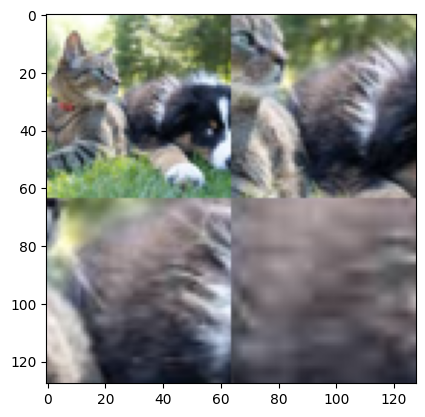

In [38]:
plt.imshow(img1_denorm.permute(0, 2, 3, 1).numpy().squeeze())

dog


/tmp/ipykernel_642275/3759898469.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img2_denorm = img2_test.cpu() * torch.tensor(std) + torch.tensor(mean)


torch.Size([1, 768]) torch.Size([1, 768])


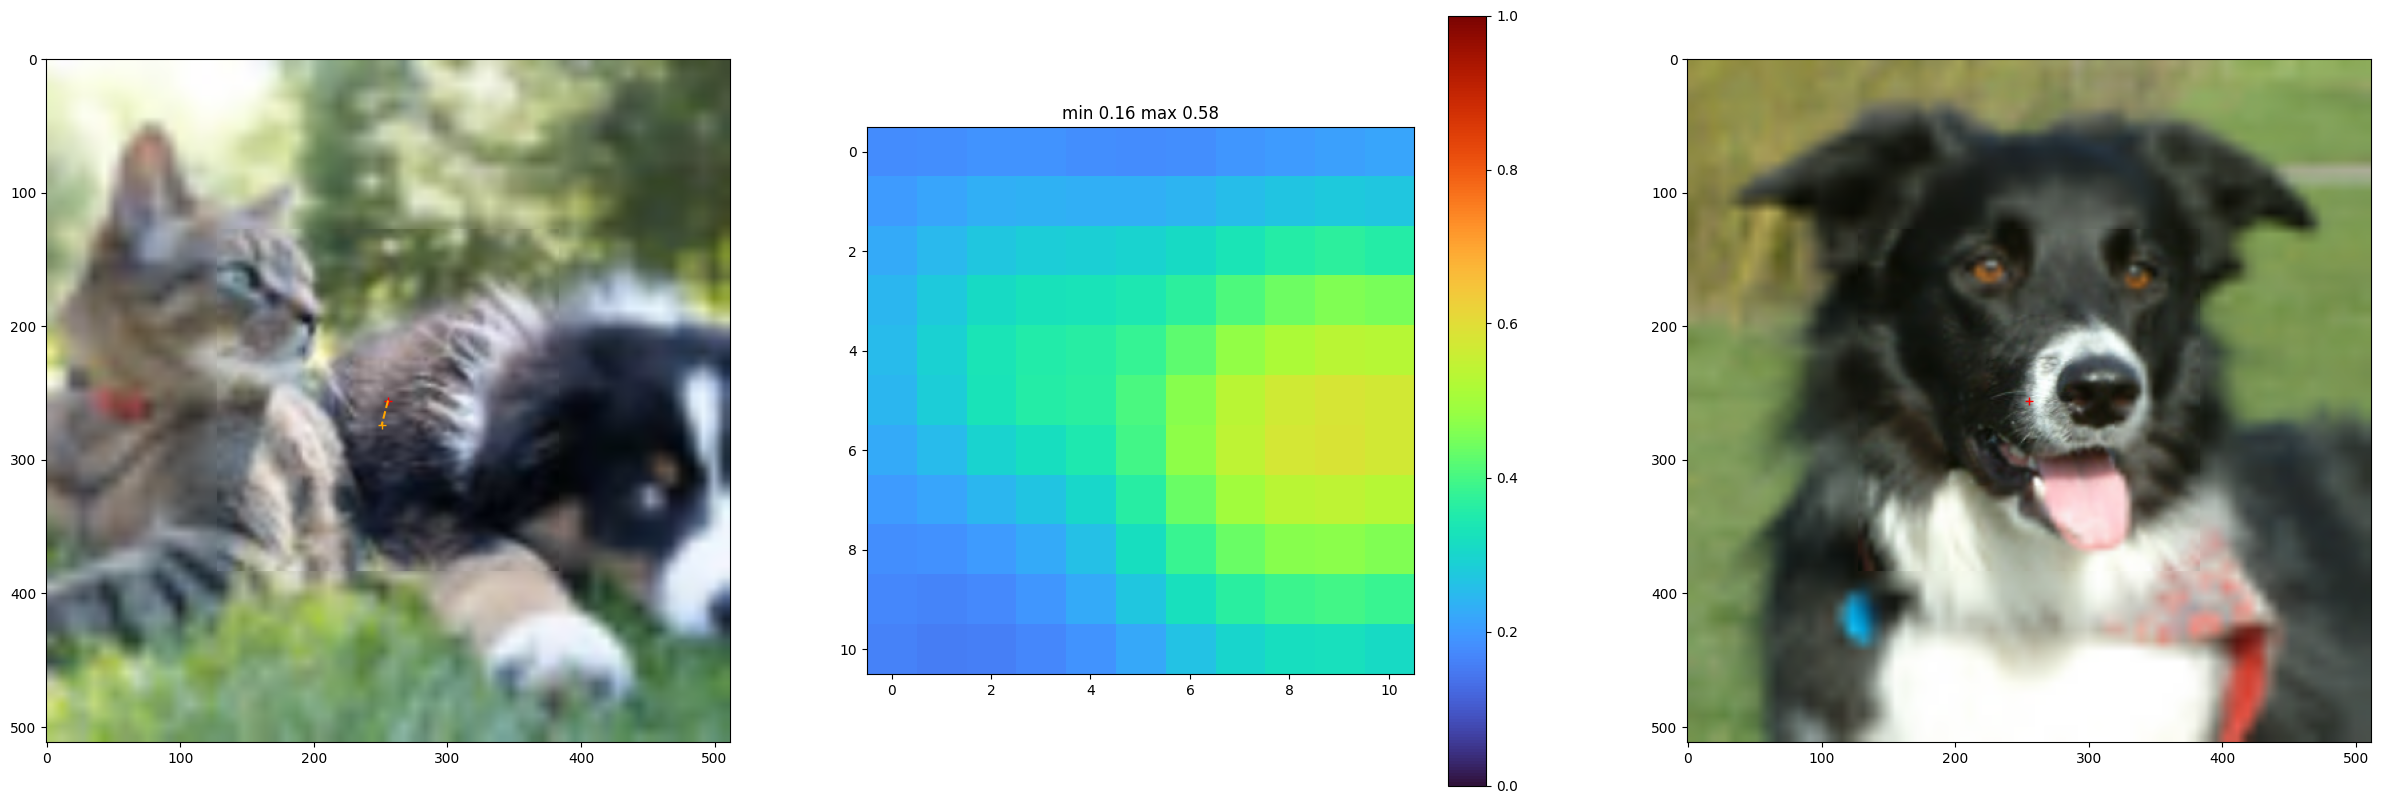

In [24]:
resolution_fov = 512

with torch.no_grad():

    for i, img_name in enumerate(('dog',)): # 'dog-1', 'dog-2', 'dog-3')):
        print(img_name)

        img2_test = load_and_transform("img/" + img_name + '.jpg', transform_test)

        z1, z1_pred_grid, z2, sal_map = compute_saliency_grid(
                dino_student_y,
                teacher_model,
                img1_test,
                img2_test,
                device=device,
                norm=True
            )
        
        img2_denorm = img2_test.cpu() * torch.tensor(std) + torch.tensor(mean)
        img2_fov = foveate_mosaic(img2_denorm)
        img2_fov = img2_fov.permute(0, 2, 3, 1).numpy()
        img2_fov = np.clip(img2_fov, 0, 1)  # s'assurer que les valeurs sont entre 0 et 1

        print(z1.shape, z2.shape)

        y_pred = mlp(z1, z2).cpu().detach().numpy()[0]
        orig = np.array((resolution_fov/2-0.5, resolution_fov/2-0.5))
        dest = orig + y_pred * resolution_fov/2 * 1/zoom

        #dest_hat = orig + np.array(y_hats[i]) * resolution_fov/2 * 1/zoom

        plt.figure(figsize=(30, 10))

        plt.subplot(1,3,1)

        plt.imshow(img1_fov[0,:])  # s'assurer que les valeurs sont entre 0 et 1
        plt.plot(orig[0], orig[1], 'r+')
        plt.plot(dest[0], dest[1], '+', color='orange')
        plt.plot((orig[0], dest[0]), (orig[1], dest[1]), '--', color='orange')
        #plt.plot((orig[0], dest_hat[0]), (orig[1], dest_hat[1]), 'b--')
        #plt.plot(dest_hat[0], dest_hat[1], 'r+')

        plt.subplot(1,3,2)
        hmap = plt.imshow(sal_map, cmap=cmap, vmin=0, vmax=1)
        plt.colorbar(hmap)
        map_size = 11

        sal_min = torch.min(sal_map).item()
        sal_max = torch.max(sal_map).item()
        plt.title(f'min {sal_min:.2f} max {sal_max:.2f}')

        plt.subplot(1,3,3)

        plt.imshow(img2_fov[0,:])
        plt.plot(orig[0], orig[1], 'r+')



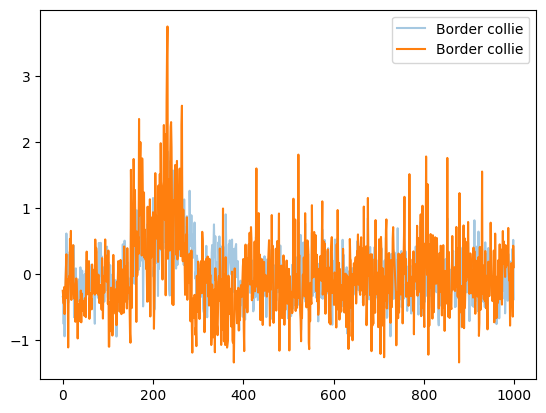

In [25]:
out_1 = z_linear_head(z1)
pred_1 = torch.argmax(out_1).item()
label_1 = classes[pred_1]
plt.plot(out_1.detach().numpy().flatten(), alpha=.4, label=label_1)
out_2 = z_linear_head(z2)
pred_2 = torch.argmax(out_2).item()
label_2 = classes[pred_2]
plt.plot(z_linear_head(z2).detach().numpy().flatten(), label=label_2)
plt.legend()


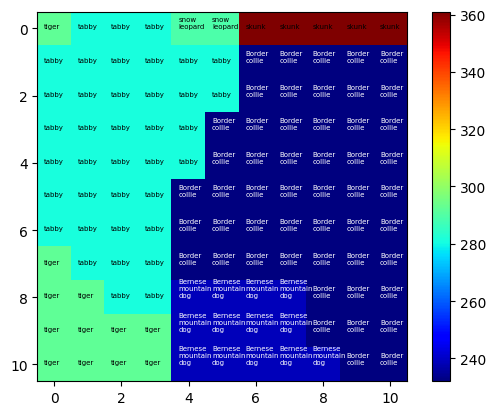

In [26]:
grid_size = 11
out_grid = z_linear_head(z1_pred_grid)
pred_grid = torch.argmax(out_grid, dim=1).detach().numpy()
pred_grid = pred_grid.reshape(grid_size, grid_size) 

plt.imshow(pred_grid, cmap='jet')
for y in range(grid_size):
    for x in range(grid_size):
        if pred_grid[y,x] < 280:
            plt.text(x-.3, y, classes[pred_grid[y,x]].replace(' ','\n'), fontsize=5, color='white')
        else:
            plt.text(x-.3, y, classes[pred_grid[y,x]].replace(' ','\n'), fontsize=5)
plt.colorbar()


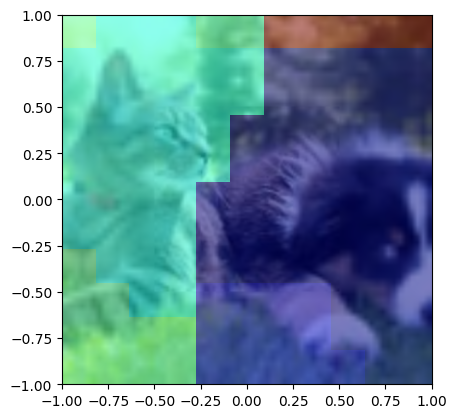

In [27]:
import matplotlib.pyplot as plt

# 1. Définir les limites du domaine
# Vos données vont de -5/6 à 5/6
lim = 1
coords = [-lim, lim, -lim, lim]

# 2. Afficher l'image de fond
# On suppose que l'image couvre le même domaine [-5/6, 5/6]
plt.imshow(img1_fov[0,:], extent=coords)

# 3. Afficher la grille par-dessus
# En utilisant le même 'extent', Matplotlib va automatiquement 
# étirer la grille 11x11 pour qu'elle corresponde exactement à cette zone
plt.imshow(pred_grid, extent=coords, alpha=0.5, cmap='jet')

plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.axis('on') # Optionnel : laissez 'on' pour vérifier que les coordonnées correspondent
plt.show()

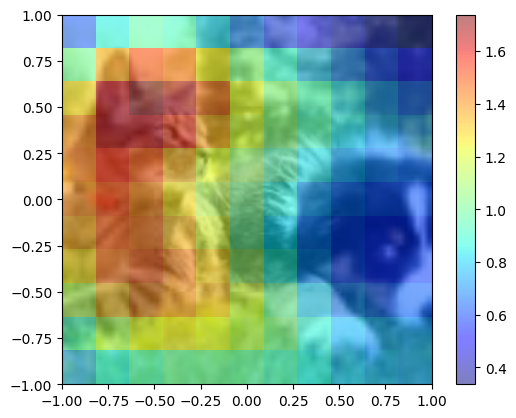

In [28]:
idx_tabby = np.where([classes[i] == 'tabby' for i in range(1000)])[0][0]
tabby_map = out_grid[:,idx_tabby]
tabby_map = tabby_map.reshape(grid_size, grid_size) 

# 1. Définir les limites du domaine
lim = 1
coords = [-lim, lim, -lim, lim]

# 2. Afficher l'image de fond
plt.imshow(img1_fov[0,:], extent=coords)


# 3. Afficher la grille par-dessus
# En utilisant le même 'extent', Matplotlib va automatiquement 
# étirer la grille 11x11 pour qu'elle corresponde exactement à cette zone
plt.imshow(tabby_map.detach().numpy(), extent=coords, alpha=0.5, cmap='jet')

plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.axis('on') # Optionnel : laissez 'on' pour vérifier que les coordonnées correspondent
plt.colorbar()


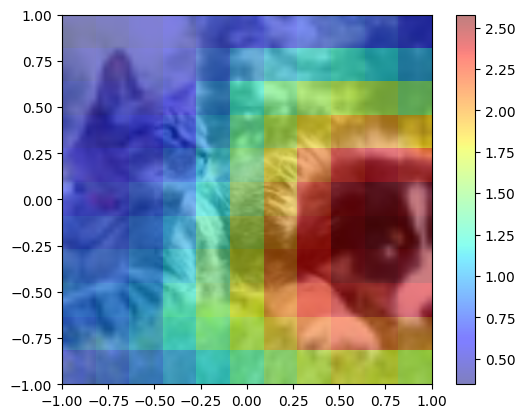

In [29]:
idx_dog = np.where([classes[i] == 'Border collie' for i in range(1000)])[0][0]
dog_map = out_grid[:,idx_dog]
dog_map = dog_map.reshape(grid_size, grid_size) 
# 1. Définir les limites du domaine
# Vos données vont de -5/6 à 5/6

# 2. Afficher l'image de fond
# On suppose que l'image couvre le même domaine [-5/6, 5/6]
plt.imshow(img1_fov[0,:], extent=coords)


# 3. Afficher la grille par-dessus
# En utilisant le même 'extent', Matplotlib va automatiquement 
# étirer la grille 11x11 pour qu'elle corresponde exactement à cette zone
plt.imshow(dog_map.detach().numpy(), extent=coords, alpha=0.5, cmap='jet')

plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.axis('on') # Optionnel : laissez 'on' pour vérifier que les coordonnées correspondent
plt.colorbar()

plt.show()



## Multi-saccades test

In [30]:
@torch.no_grad()
def compute_norm_grid(
    dino_student_y,
    img1,
    grid_size=11,
    y_min=-5/6, y_max=5/6,
    device='cuda'
):
    device = next(dino_student_y.parameters()).device
    img1   = img1.to(device)

    # ── normalisation batch dim ───────────────────────────────────────
    if img1.ndim == 3:
        img1 = img1.unsqueeze(0)          # (1, C, H, W)
    B = img1.shape[0]

    # ── grille de positions ───────────────────────────────────────────
    xs       = torch.linspace(y_min, y_max, grid_size, device=device)
    ys       = torch.linspace(y_min, y_max, grid_size, device=device)
    X, Y     = torch.meshgrid(xs, ys, indexing="xy")
    grid     = torch.stack([X, Y], dim=-1)     # (G, G, 2)
    grid_flat = grid.reshape(-1, 2)            # (G*G, 2)
    G2       = grid_flat.shape[0]              # G*G = 121

    # ── répéter images et positions pour forward vectorisé ───────────
    # img1     : (B, C, H, W) → (B*G*G, C, H, W)
    # grid_flat: (G*G, 2)     → (B*G*G, 2)
    img1_rep  = img1.unsqueeze(1).expand(B, G2, -1, -1, -1) \
                    .reshape(B * G2, *img1.shape[1:])         # (B*G*G, C, H, W)
    grid_rep  = grid_flat.unsqueeze(0).expand(B, G2, 2) \
                         .reshape(B * G2, 2)                  # (B*G*G, 2)

    # ── forward ──────────────────────────────────────────────────────
    _, z_y = dino_student_y(img1_rep, grid_rep, layernorm=False)  # (B*G*G, D)

    # ── reshape → (B, G, G, D) ───────────────────────────────────────
    D      = z_y.shape[-1]
    z_y    = z_y.reshape(B, grid_size, grid_size, D)              # (B, G, G, D)

    # ── saliency = norme L2 par position ─────────────────────────────
    saliency = torch.linalg.norm(z_y, dim=-1)                     # (B, G, G)

    # ── position maximale par image ───────────────────────────────────
    # argmax sur la grille aplatie
    flat_idx = saliency.reshape(B, -1).argmax(dim=1)              # (B,)
    i_star   = flat_idx // grid_size                              # ligne   (B,)
    j_star   = flat_idx  % grid_size                              # colonne (B,)
    x_star   = xs[j_star]                                         # (B,) — axe x = colonnes
    y_star   = ys[i_star]                                         # (B,) — axe y = lignes

    return {
        "grid"     : grid,                    # (G, G, 2)
        "z_y"      : z_y,                     # (B, G, G, D)
        "saliency" : saliency,                # (B, G, G)
        "i_star"   : i_star,                  # (B,) indices ligne
        "j_star"   : j_star,                  # (B,) indices colonne
        "x_star"   : x_star,                  # (B,) coordonnée x optimale
        "y_star"   : y_star,                  # (B,) coordonnée y optimale
    }


     # (B,)

In [31]:
# ── utilisation ───────────────────────────────────────────────────────────
# single image
result = compute_norm_grid(dino_student_y, img1_test)          # img1 (C,H,W) ou (1,C,H,W)
print(result["x_star"], result["y_star"])                  # (1,) (1,)

                    

tensor([0.5000]) tensor([2.9802e-08])


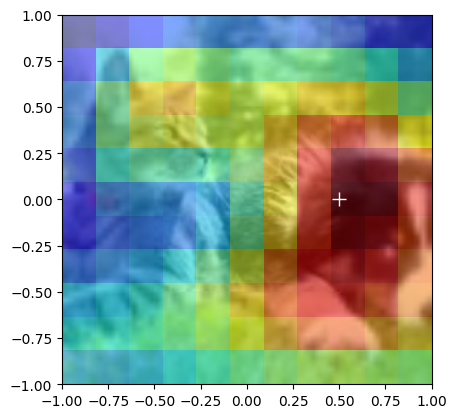

In [32]:
plt.imshow(img1_fov[0,:], extent=coords)
plt.imshow(result["saliency"].squeeze(0).detach().numpy(), extent=coords, alpha=0.5, cmap='jet')
plt.plot(result["x_star"], result["y_star"],'+w', markersize=10)                  # (1,) (1,)


In [33]:
# ── utilisation ───────────────────────────────────────────────────────────
# single image
result = compute_norm_grid(dino_student_y, img2_test)          # img1 (C,H,W) ou (1,C,H,W)
print(result["x_star"], -result["y_star"])                  # (1,) (1,)

                    

tensor([-0.3333]) tensor([0.3333])


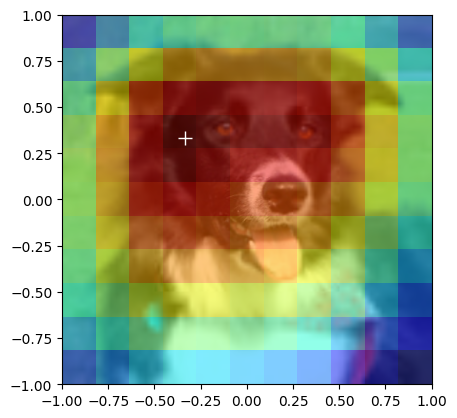

In [34]:
plt.imshow(img2_fov[0,:], extent=coords)
plt.imshow(result["saliency"].squeeze(0).detach().numpy(), extent=coords, alpha=0.5, cmap='jet')
plt.plot(result["x_star"], -result["y_star"],'+w', markersize=10)                  # (1,) (1,)


In [35]:
def shift_zoom(img, x, y, zoom):
        w, h = img.size
        size_ref = min(w, h)
        w_zoomed   = int(w * zoom)
        h_zoomed   = int(h * zoom)
        zoomed_ref = min(w_zoomed, h_zoomed)   # petit côté zoomé — référence du shift

        img_zoomed = FF.resize(img, (h_zoomed, w_zoomed),
                            interpolation=Image.BICUBIC)
        y_prim = y

        # centre de fixation dans l'espace zoomé
        # x,y ∈ [-1,1] définis par rapport au petit côté original
        cx = w_zoomed / 2 + zoomed_ref * x / 2 #zoomed_ref / 2 * (1 + x / 2)   # ∈ [zoomed_ref/4, 3*zoomed_ref/4]
        cy = h_zoomed / 2 + zoomed_ref * y_prim / 2 #zoomed_ref / 2 * (1 + y / 2)

        # crop de taille originale (w, h) centré en (cx, cy)
        left   = int(cx - size_ref/2) #w / 2)
        top    = int(cy - size_ref/2) #h / 2)
        right  = left + size_ref #w
        bottom = top  + size_ref #h

        # padding reflect uniquement si on dépasse l'image zoomée réelle
        pl = max(0, -left);             
        pt = max(0, -top)
        pr = max(0, right  - w_zoomed); 
        pb = max(0, bottom - h_zoomed)

        if any([pl, pt, pr, pb]):
            img_zoomed = FF.pad(img_zoomed, (pl, pt, pr, pb),
                                padding_mode='reflect')
        left += pl
        top  += pt

        return img_zoomed.crop((left, top, left + size_ref, top + size_ref))

In [36]:
def collate_pil(batch):
    """Retourne une liste de PIL Images et un tenseur de labels."""
    imgs   = [b[0] for b in batch]   # liste de PIL Images
    labels = torch.tensor([b[1] for b in batch])
    return imgs, labels

In [37]:
@torch.no_grad()
def evaluate_saccade(
    dino_student_y,
    z_linear_head,
    val_dataset_raw,
    fovea_transform,
    zoom       = 1.5,
    grid_size  = 11,
    batch_size = 32,
    device     = 'cuda',
    num_workers = 4
):

    dino_student_y.eval()
    z_linear_head.eval()

    correct_center  = 0
    correct_saccade = 0
    total           = 0

    loader = DataLoader(
        val_dataset_raw,
        batch_size  = batch_size,
        shuffle     = True,
        num_workers = num_workers,
        collate_fn  = collate_pil,   
    )

    pbar = tqdm(loader, desc="Évaluation saccade")

    for imgs_pil, labels in pbar:
        # imgs_pil : liste de B PIL images (collate par défaut)
        labels = labels.to(device)
        B      = labels.shape[0]

        # ── 1. vue centrale (x=0, y=0) ───────────────────────────────────
        mosaics_center = []
        for img in imgs_pil:
            img_center  = shift_zoom(img, 0.0, 0.0, zoom)
            mosaic     = fovea_transform(img_center)
            mosaics_center.append(mosaic)

        mosaics_center = torch.stack(mosaics_center).to(device)  # (B, 3, H, W)
        print(mosaics_center.shape)

        # forward student — vue centrale
        z_center = teacher_model(mosaics_center)             # (B, D)
        print(z_center.shape)

        logits_center = z_linear_head(z_center)                  # (B, 1000)
        print(logits_center.shape)
        pred_center   = logits_center.argmax(dim=1)
        correct_center += (pred_center == labels).sum().item()

        # ── 2. compute_norm_grid → position optimale ──────────────────────
        print(f"compute norm grid")
        result = compute_norm_grid(
            dino_student_y,
            mosaics_center,
            grid_size = grid_size,
            device    = device,
        )

        for b,img in enumerate(imgs_pil):
            img_center  = shift_zoom(img, 0.0, 0.0, zoom)
            mosaic     = fovea_transform(img_center)
            img_denorm = mosaic.cpu() * torch.tensor(std) + torch.tensor(mean)
            img_fov = foveate_mosaic(img_denorm)
            img_fov = img_fov.permute(0, 2, 3, 1).numpy()
            img_fov = np.clip(img_fov, 0, 1)
            plt.figure()
            plt.imshow(img_fov[0,:], extent=coords)
            plt.imshow(result["saliency"][b,:,:].detach().numpy(), extent=coords, alpha=0.5, cmap='jet')
            plt.plot(result["x_star"][b], -result["y_star"][b],'+w', markersize=10)    

        x_star = result["x_star"]/zoom   # (B,)
        y_star = result["y_star"]/zoom   # (B,)

        # ── 3. vue saccadée (x_star, y_star) ─────────────────────────────
        mosaics_saccade = []
        for b, img in enumerate(imgs_pil):
            print(f"image {b}/{batch_size} : ({x_star[b].item()}, {y_star[b].item()})")
            img_shift = shift_zoom(img,
                                   x_star[b].item(),
                                   y_star[b].item(),
                                   zoom)
            mosaic    = fovea_transform(img_shift)
            mosaics_saccade.append(mosaic)

        mosaics_saccade = torch.stack(mosaics_saccade).to(device)  # (B, 3, H, W)

        # forward student — vue saccadée
        y_target = torch.stack([x_star, y_star], dim=1).to(device)  # (B, 2)
        z_star = teacher_model(mosaics_saccade)                   # (B, D)

        logits_saccade = z_linear_head(z_star)                       # (B, 1000)
        pred_saccade   = logits_saccade.argmax(dim=1)
        correct_saccade += (pred_saccade == labels).sum().item()

        total += B

        pbar.set_postfix({
            "acc_center"  : f"{100*correct_center/total:.2f}%",
            "acc_saccade" : f"{100*correct_saccade/total:.2f}%",
        })

        break # !! TEST

    acc_center  = 100 * correct_center  / total
    acc_saccade = 100 * correct_saccade / total

    print(f"\n── Résultats ───────────────────────────────────────────────")
    print(f"  Accuracy centre   : {acc_center:.2f}%")
    print(f"  Accuracy saccade  : {acc_saccade:.2f}%")
    print(f"  Delta             : {acc_saccade - acc_center:+.2f}%")

    return {
        "acc_center"  : acc_center,
        "acc_saccade" : acc_saccade,
        "delta"       : acc_saccade - acc_center,
        "n_images"    : total,
    }



In [ ]:
# ── lancement ─────────────────────────────────────────────────────────────
results = evaluate_saccade(
    dino_student_y  = dino_student_y,
    z_linear_head   = z_linear_head,
    val_dataset_raw = val_dataset_raw,
    fovea_transform = transform_test,
    zoom            = 1.5,
    grid_size       = 11,
    batch_size      = 32,
    device          = device,
    num_workers     = num_workers
)

Évaluation saccade:   0%|          | 0/1563 [00:00<?, ?it/s]

torch.Size([32, 3, 128, 128])
torch.Size([32, 768])
torch.Size([32, 1000])
compute norm grid


## IST Transformer

In [39]:

classes = ResNet50_Weights.DEFAULT.meta['categories']

def find_class_idx(name, classes):
    return [(i, c) for i, c in enumerate(classes) if name.lower() in c.lower()]

print(find_class_idx('cat', classes))
print(find_class_idx('tabby', classes))

[(143, 'oystercatcher'), (282, 'tiger cat'), (283, 'Persian cat'), (284, 'Siamese cat'), (285, 'Egyptian cat'), (358, 'polecat'), (383, 'Madagascar cat'), (484, 'catamaran')]
[(281, 'tabby')]


In [40]:
use_synset_embeddings = False

In [41]:
k = 3
n_heads = 12
n_sab = 2

embed_dim = 768

if use_synset_embeddings:
    weights_dir ="260720_ISTW_3_semi_z_lam0.05_mu_1_sab2_LeJ_POS_SUP_TEST_CROSS_SMOOTH0.1_SYNSET4_ASEED_APOS2_ALAB2_s3_t5_space"
    #weights_dir = "260716_ISTQ_3_semi_z_lam0.05_mu_1_sab2_LeJ_POS_SUP_a3e-06_TEST_CROSS_RES_SMOOTH0.8_SYNSET4_ASEED_APOS2_s3_t5_space"
    epoch_ist = 30
    abmil_pos = True
    abmil_label = True
    #weights_dir = "260715_ISTQ_3_semi_z_lam0.05_mu_1_sab2_LeJ_POS_SUP_a3e-06_TEST_CROSS_RES_SMOOTH0.5_SYNSET4_APOS2_s3_t5_space"
    full_residual = False
    #weights_dir = "260712_ISTQ_3_semi_z_lam0.05_mu_1_sab2_LeJ_TEST_CROSS_FULL_RES_SMOOTH0.5_SYNSET4_APOS2_s3_t5_space"
    #weights_dir = "260711_ISTQ_3_semi_z_lam0.05_mu_1_sab2_LeJ_SUP_a3e-06_TEST_CROSS_RES_SMOOTH0.5_SYNSET4_APOS2_s3_t5_space"
    #weights_dir = "260711_ISTQ_3_semi_z_lam0.05_mu_1_sab2_LeJ_SUP_a3e-06_TEST_CROSS_RES_DETACH_SMOOTH0.5_SYNSET4_SIMPLE_APOS2_s3_t5_space"
    #weights_dir = "260707_ISTQ_3_semi_z_lam0.05_mu_1_sab2_LeJ_SUP_a3e-06_TEST_CROSS_RES_DETACH_SMOOTH0.5_SYNSET_APOS2_s3_t5_space"
    synset_level = 4
    #full_residual = True
    #weights_dir = "260708_ISTQ_3_semi_z_lam0.05_mu_1_sab2_LeJ_SUP_a3e-06_TEST_CROSS_RES_DETACH_SMOOTH0.5_SYNSET6_APOS2_s3_t5_space"
    #synset_level = 6
    #weights_dir = "260709_ISTQ_3_semi_z_lam0.05_mu_1_sab2_LeJ_SUP_a3e-06_TEST_CROSS_RES_DETACH_SMOOTH0.5_INDEX_SYNSET8_APOS2_s3_t5_space"
    #synset_level = 8
    #epoch_ist = 30
else:
    #weights_dir = "260630_ISTQ_3_semi_z_lam0.05_mu_1_sab2_LeJ_SUP_a3e-06_TEST_CROSS_RES_DETACH_SMOOTH_APOS2_s3_t5_space_(*)"
    #weights_dir = "260702_ISTQ_3_semi_z_lam0.05_mu_1_sab2_LeJ_SUP_a3e-06_TEST_CROSS_RES_DETACH_SMOOTH0.8_APOS2_s3_t5_space"
    #epoch_ist = 100
    '''weights_dir = "260712_ISTQ_3_semi_z_lam0.05_mu_1_sab2_LeJ_TEST_CROSS_RES_SMOOTH0.5_APOS2_s3_t5_space"
    epoch_ist = 30
    residual = True
    full_residual = False'''
    #weights_dir = "260718_ISTQ_3_semi_z_lam0.05_mu_1_sab2_LeJ_POS_SUP_a3e-06_TEST_CROSS_SMOOTH0.8_ASEED_s3_t5_space"
    weights_dir = "260722_ISTW_3_semi_z_lam0.05_mu_1_sab2_LeJ_POS_SUP_TEST_CROSS_SMOOTH0.1_INDEX_ASEED_APOS2_ALAB2_s3_t5_space"
    epoch_ist = 30
    abmil_pos = True
    abmil_label = True
    #residual = False
    #full_residual = False
    #abmil_pos = False



l_emb_detach = False
label_smoothing = 0.8




load_dir = "../checkpoints/" + weights_dir
checkpoint_path = os.path.join(load_dir, f"checkpoint_epoch{epoch_ist}.pt")  # exemple
checkpoint = torch.load(checkpoint_path, map_location="cpu")
print("Clés du checkpoint :", checkpoint.keys())

Clés du checkpoint : dict_keys(['epoch', 'history', 'ist_transformer', 'draws_attention', 'seeds_mlp', 'linear_head', 'pos_predictor', 'heads_per_seed'])


In [42]:
checkpoint_path

'../checkpoints/260722_ISTW_3_semi_z_lam0.05_mu_1_sab2_LeJ_POS_SUP_TEST_CROSS_SMOOTH0.1_INDEX_ASEED_APOS2_ALAB2_s3_t5_space/checkpoint_epoch30.pt'

In [43]:
import os
os.listdir()

['02_pos_embed_sanity_check.ipynb',
 'saccades_visualization.png',
 'imagenet_synset_2_embeddings.pt',
 'imagenet_synset_4_embeddings.pt.bak',
 'imagenet_synset_4_embeddings.pt',
 '01_saccades_visualization.ipynb',
 '01_saccades_visualization.ipynb.bak',
 'img',
 'imagenet_synset_6_embeddings.pt',
 '03_results_analysis.ipynb',
 'imagenet_synset_8_embeddings.pt',
 '01_teacher_one_saccade_estimation.ipynb']

In [44]:
if use_synset_embeddings:
    data = torch.load(f'imagenet_synset_{synset_level}_embeddings.pt')
    label_to_synset_tensor = data['label_to_synset'].to(device)
    n_synsets              = data['n_synsets']
    synset_names           = data['synset_names']
    synset_embeddings      = data['embeddings'].to(device)    

    #print(synset_names.index('cat'))
    #print(synset_names.index('domestic cat'))
    # level 4
    print(synset_names.index('dog'))
    print(synset_names.index('carnivore'))
    print(synset_names.index('bird'))
    # level 6
    #print(synset_names.index('canine'))
    #print(synset_names.index('carnivore'))
    # level 8
    #print(synset_names.index('placental'))
    #print(synset_names.index('vertebrate'))
    #print(synset_names.index('animal'))


In [45]:
use_synset_embeddings

False

In [46]:
'''if use_synset_embeddings:
    ist_transformer = IterativeSeedTransformerwithQuery(n_heads=n_heads, 
                                                    n_seeds=k, 
                                                    n_blocks=n_sab, 
                                                    pretrained_embeddings=None,
                                                    n_classes=n_synsets,
                                                    residual=residual, 
                                                    full_residual=full_residual,
                                                    l_emb_detach=l_emb_detach, 
                                                    label_smoothing=label_smoothing)
else:
    ist_transformer = IterativeSeedTransformerwithQuery(n_heads=n_heads, 
                                                    n_seeds=k, 
                                                    n_blocks=n_sab, 
                                                    pretrained_embeddings=None,
                                                    residual=residual, 
                                                    full_residual=full_residual,
                                                    l_emb_detach=l_emb_detach, 
                                                    label_smoothing=label_smoothing)'''
if use_synset_embeddings:
    ist_transformer = WhereIterativeSeedTransformer(n_heads=n_heads, 
                                                    n_seeds=k, 
                                                    n_blocks=n_sab, 
                                                    pretrained_embeddings=None,
                                                    n_classes=n_synsets,
                                                    label_smoothing=label_smoothing)
else:
    ist_transformer = WhereIterativeSeedTransformer(n_heads=n_heads, 
                                                    n_seeds=k, 
                                                    n_blocks=n_sab, 
                                                    pretrained_embeddings=None,
                                                    label_smoothing=label_smoothing)
for param in ist_transformer.parameters():
        param.requires_grad = False

if "ist_transformer" not in checkpoint:
    raise KeyError(f"Aucune clé 'ist_transformer' trouvée dans {checkpoint_path}")
state_dict = checkpoint["ist_transformer"]
missing, unexpected = ist_transformer.load_state_dict(state_dict, strict=False)
print("➡️ Poids chargés (ist_transformer).")
print("❗ Paramètres manquants :", missing)
print("⚠️ Paramètres inattendus :", unexpected)

ist_transformer.to(device)
ist_transformer.eval()

➡️ Poids chargés (ist_transformer).
❗ Paramètres manquants : []
⚠️ Paramètres inattendus : []


WhereIterativeSeedTransformer(
  (pre_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (pre_ffn): Sequential(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=3072, out_features=768, bias=True)
    (4): Dropout(p=0.8, inplace=False)
  )
  (label_embedding): Embedding(1000, 768)
  (blocks): ModuleList(
    (0-1): 2 x WhereBlock(
      (view_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (view_self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
      (view_norm_ffn): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (view_ffn): Sequential(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=3072, out_features=768, bias=Tr

In [47]:
'''linear_head = nn.Sequential(
                    nn.LayerNorm(embed_dim),                  
                    nn.Linear(embed_dim, 1000),
                )'''

if abmil_label:
    linear_head = ABMILLabelPredictor(emb_dim=embed_dim, k=k)

if "linear_head" not in checkpoint:
    raise KeyError(f"Aucune clé 'linear_head' trouvée dans {checkpoint_path}")
state_dict = checkpoint["linear_head"]
missing, unexpected = linear_head.load_state_dict(state_dict, strict=False)
print("➡️ Poids chargés (linear_head).")
print("❗ Paramètres manquants :", missing)
print("⚠️ Paramètres inattendus :", unexpected)

linear_head.to(device)
linear_head.eval()


➡️ Poids chargés (linear_head).
❗ Paramètres manquants : []
⚠️ Paramètres inattendus : []


ABMILLabelPredictor(
  (label_transform): Sequential(
    (0): Linear(in_features=768, out_features=768, bias=True)
    (1): ReLU()
    (2): Linear(in_features=768, out_features=768, bias=True)
  )
  (norm_label): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (norm_s): ModuleList(
    (0-2): 3 x LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (seed_transform): ModuleList(
    (0-2): 3 x Sequential(
      (0): Linear(in_features=768, out_features=768, bias=True)
      (1): ReLU()
      (2): Linear(in_features=768, out_features=768, bias=True)
    )
  )
  (attn): Sequential(
    (0): Linear(in_features=1536, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [48]:
if abmil_pos:
    pos_predictor = ABMILPosPredictor(embed_dim, k)
else:
    pos_predictor = nn.Sequential(
                nn.LayerNorm(embed_dim),  
                nn.Linear(embed_dim, 256),
                nn.ReLU(),
                nn.Linear(256, 2),
            )

if "pos_predictor" not in checkpoint:
    raise KeyError(f"Aucune clé 'pos_predictor' trouvée dans {checkpoint_path}")
state_dict = checkpoint["pos_predictor"]
missing, unexpected = pos_predictor.load_state_dict(state_dict, strict=False)
print("➡️ Poids chargés (pos_predictor).")
print("❗ Paramètres manquants :", missing)
print("⚠️ Paramètres inattendus :", unexpected)

pos_predictor.to(device)
pos_predictor.eval()

➡️ Poids chargés (pos_predictor).
❗ Paramètres manquants : []
⚠️ Paramètres inattendus : []


ABMILPosPredictor(
  (norm_s): ModuleList(
    (0-2): 3 x LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (norm_z): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attn): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
  (combine): Sequential(
    (0): Linear(in_features=1024, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
  )
  (seed_transform): ModuleList(
    (0-2): 3 x Sequential(
      (0): Linear(in_features=768, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (z_transform): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
  )
  (head): Linear(in_features=512, out_features=2, bias=True)
)

281
tensor([[-0.1182, -0.0029]]) tensor([232])


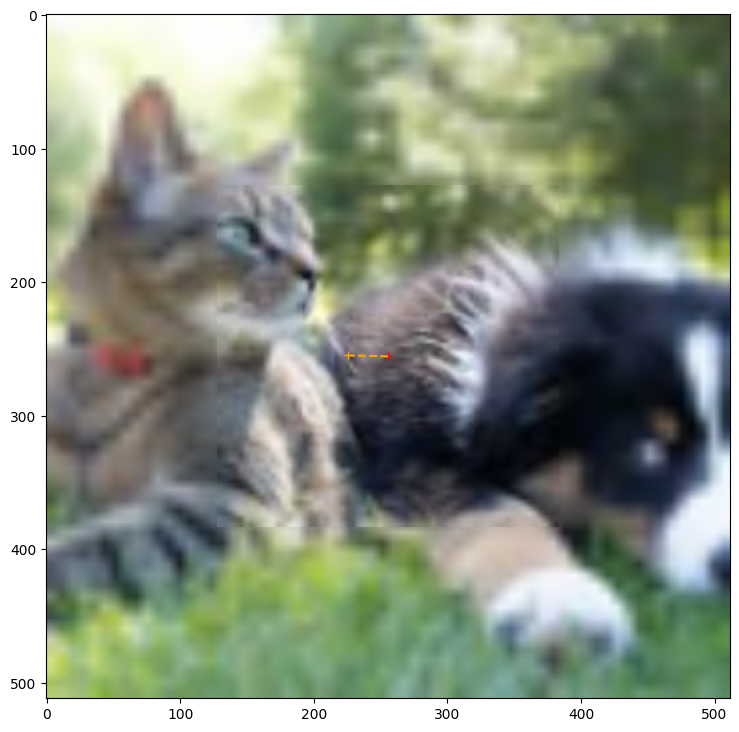

In [49]:
resolution_fov = 512

img = load_and_transform("img/dog-cat.jpg", transform_test) 

with torch.no_grad():

    img = img.unsqueeze(0)
    img = img.to(device)
    z = teacher_model.forward_features(img)[:, 0, :].unsqueeze(1)     

    if use_synset_embeddings: 
        label = 'dog' #None #'carnivore' #'ruminant' #'placental' #'feline' # #'canine' #
        if label is not None:
            in_label = torch.tensor(synset_names.index(label), dtype=int).unsqueeze(0)
        else:
            in_label = None
    else:
        label = 'tabby' #'Border collie' #
        in_label = torch.tensor(find_class_idx(label, classes)[0][0], dtype=int).unsqueeze(0)
        print(find_class_idx(label, classes)[0][0])
        

    z_seeds = ist_transformer(
                    z, in_label
                )
    
    z_pos_in = z_seeds[:, k, :] 
    if abmil_label:
        logits, _ = linear_head(z_seeds[:, :k, :], z_pos_in)

    if abmil_pos:
        pos_out, _ = pos_predictor(z_seeds[:,:k,:], z_pos_in)
    else:
        pos_out = pos_predictor(z_pos_in)
                #print(pos_out[0,:].cpu().detach().numpy())
    preds  = logits.argmax(dim=1)

    print(pos_out, preds)

    orig = np.array((resolution_fov/2-0.5, resolution_fov/2-0.5))
    dest = orig + pos_out.unsqueeze(0).detach().numpy() * resolution_fov/2 * 1/zoom
    dest = dest.flatten()

    #dest_hat = orig + np.array(y_hats[i]) * resolution_fov/2 * 1/zoom

    plt.figure(figsize=(30, 10))

    plt.subplot(1,3,1)

    plt.imshow(img1_fov[0,:])  # s'assurer que les valeurs sont entre 0 et 1
    plt.plot(orig[0], orig[1], 'r+')
    plt.plot(dest[0], dest[1], '+', color='orange')
    plt.plot((orig[0], dest[0]), (orig[1], dest[1]), '--', color='orange')




(-3.0, 3.0)

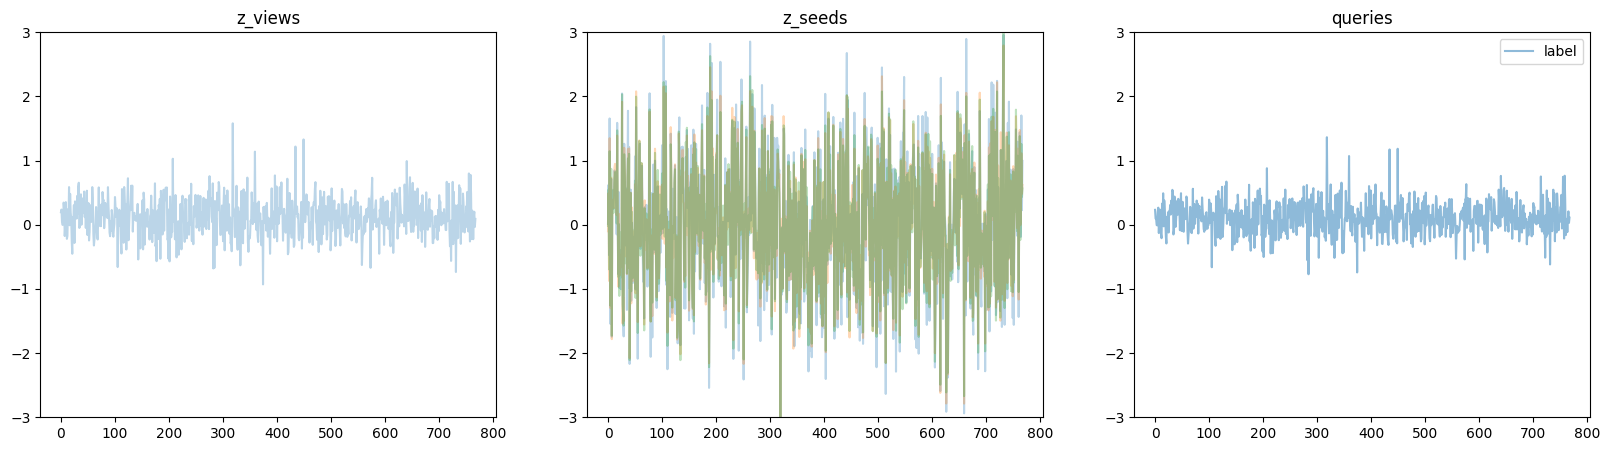

In [50]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
for i in range(1):
    plt.plot(z[0,i,:], alpha=.3) 
plt.title('z_views')
plt.ylim(-3,3)
plt.subplot(1,3,2)
for i in range(k):
    plt.plot(z_seeds[0,i,:], alpha=.3) 
plt.title('z_seeds')
plt.ylim(-3,3)
plt.subplot(1,3,3)
query_name = ['label', 'pos']
for i in range(k,k+1):
    plt.plot(z_seeds[0,i,:],alpha=.5,label=query_name[i-k])
plt.title('queries')
plt.legend() 
plt.ylim(-3,3)



## Multi-saccades

281
tensor([ 0.4180, -0.2246]) tensor([285])
[137.  91.] [194.25915146  60.22897339]


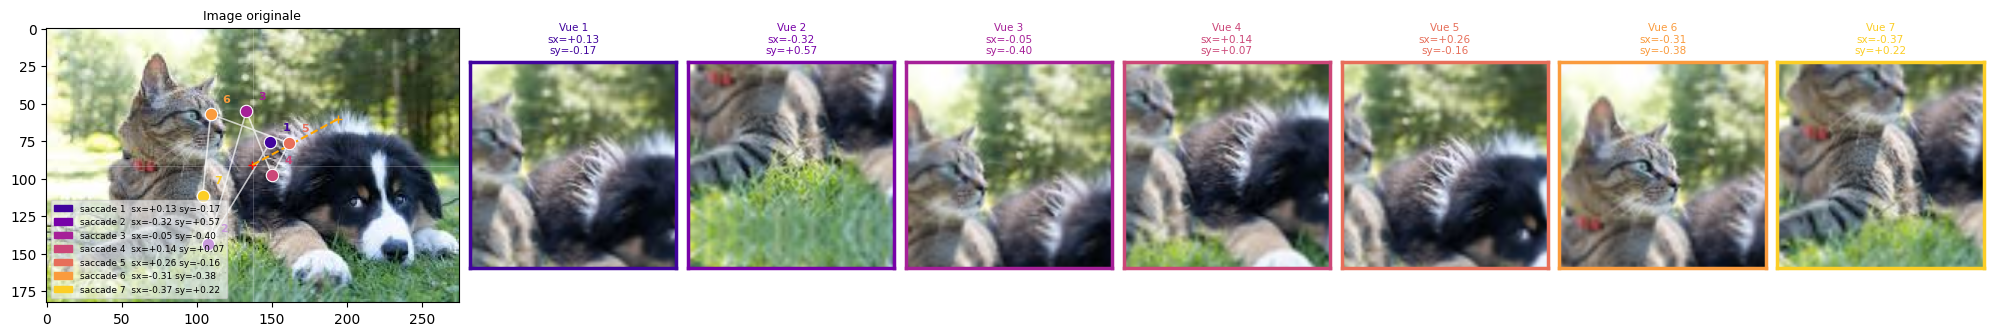

In [50]:
resolution_fov = 512

with torch.no_grad():

    img = Image.open("img/dog-cat.jpg").convert("RGB")
    #img = Image.open("img/cow.jpg").convert("RGB") # ungulate vs conveyance
    img_np  = np.array(img)                  # (512, 512, 3)  uint8


    zoom = 1.5
    std = 0.5 / zoom
    n_views = 7

    sz = ShiftZoomUplet(zoom=zoom, std=std, n_uplet=n_views)
    #np.random.seed(seed)
    views = sz(img)   # liste de (pil_shifted, sx, sy, zoom)

    W, H   = img.size   
    fix_pts = []
    for _, sx, sy, _ in views:
        #zoomed_ref = min(int(W * zoom), int(H * zoom))
        #cx = zoomed_ref / 2 * (1 + sx / 2)
        #cy = zoomed_ref / 2 * (1 + sy / 2)
        w_zoomed   = int(W * zoom)
        h_zoomed   = int(H * zoom)
        zoomed_ref = min(w_zoomed, h_zoomed)   # petit côté zoomé — référence du shift
        cx = w_zoomed / 2 + zoomed_ref * sx / 2 #zoomed_ref / 2 * (1 + x / 2)   # ∈ [zoomed_ref/4, 3*zoomed_ref/4]
        sy_prim = sy ## !! (no) sign inversion
        cy = h_zoomed / 2 + zoomed_ref * sy_prim / 2 #zoomed_ref / 2 * (1 + y / 2)
        # ramener dans le repère image originale (avant zoom)
        cx_orig = cx / zoom
        cy_orig = cy / zoom
        fix_pts.append((cx_orig, cy_orig))

    fov_tf = val_dataset.fovea_transform
    post_process = val_dataset.post_process

    z_views = []
    mosaics = []
    for pil_shifted, sx, sy, z in views:
        mosaic = fov_tf(pil_shifted)         # PIL 128×128
        mosaic = post_process(mosaic)
        mosaics.append(mosaic)
        #z = teacher_model.forward_features(mosaic.unsqueeze(0))
        z = teacher_model(mosaic.unsqueeze(0))
        z_views.append(z)

    mosaics = torch.stack(mosaics).unsqueeze(0)   # (1, V, 3, 128, 128)
    z_views = torch.stack(z_views, dim=1)
    # foveate_mosaic attend (B, C, H, W) — on boucle sur les vues
    fov_imgs = []
    for v in range(n_views):
        mosaic_v  = mosaics[0, v].unsqueeze(0)    # (1, 3, 128, 128)
        mosaic_d  = denormalize(mosaic_v[0]).unsqueeze(0)  # dénorm avant foveate
        fov_out   = foveate_mosaic(mosaic_d)       # (1, 3, 512, 512)
        fov_np    = fov_out[0].permute(1, 2, 0).numpy()   # (512,512,3)
        fov_np    = np.clip(fov_np, 0, 1)
        fov_imgs.append(fov_np)

    
    if use_synset_embeddings: 
        label = 'dog' #'carnivore' #None # #'ruminant' #'feline' #'placental' #'dog' #'wheeled vehicle' # 'conveyance' #'ungulate' #'canine' #'carnivore' # 
        if label is not None:
            in_label = torch.tensor(synset_names.index(label), dtype=int).unsqueeze(0)
        else:
            in_label = None
    else:
        label = 'tabby' #None #'Border Collie' #'Greater Swiss Mountain dog' # 
        if label is not None:
            in_label = torch.tensor(find_class_idx(label, classes)[0][0], dtype=int).unsqueeze(0)
            print(find_class_idx(label, classes)[0][0])
        else:
            in_label = None

    z_seeds = ist_transformer(
                    z_views, in_label
                )
    
    z_pos_in = z_seeds[:, k, :] 
    if abmil_label:
        logits, _ = linear_head(z_seeds[:, :k, :], z_pos_in)

    if abmil_pos:
        pos_out, _ = pos_predictor(z_seeds[:,:k,:], z_pos_in)
    else:
        pos_out = pos_predictor(z_pos_in)
                #print(pos_out[0,:].cpu().detach().numpy())
    preds  = logits.argmax(dim=1)

    pos_out = pos_out.squeeze(0)
    # pos_out[1] = -pos_out[1] # !! (no) sign inversion !!
    print(pos_out, preds)

    orig = np.array((W/2-0.5, H/2-0.5))
    resolution = min(w_zoomed, h_zoomed)
    dest = orig + pos_out.detach().numpy() * resolution/2 
    dest = dest.flatten()
    print(orig, dest)


    # ── 4. Figure ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(4 + 3 * n_views, 4))
    # grille : 1 colonne pour l'original + n_views colonnes pour les vues
    gs  = fig.add_gridspec(1, 1 + n_views, wspace=0.05,
                           width_ratios=[2] + [1] * n_views)

    # ── Panneau gauche : image originale + saccades ──────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img_np) #, origin='lower')

    colors = plt.cm.plasma(np.linspace(0.1, 0.9, n_views))

    xs_plot = [pt[0] for pt in fix_pts]
    ys_plot = [pt[1] for pt in fix_pts]

    # trajectoire
    ax0.plot(xs_plot, ys_plot,
             color='white', linewidth=1.2, alpha=0.7, zorder=2)

    # points de fixation numérotés
    for i, (px, py) in enumerate(fix_pts):
        ax0.scatter(px, py, color=colors[i], s=80, zorder=3,
                    edgecolors='white', linewidths=0.8)
        ax0.text(px + 8, py - 8, str(i + 1),
                 color=colors[i], fontsize=8, fontweight='bold',
                 zorder=4)

    # croix au centre
    ax0.axhline(H / 2, color='white', linewidth=0.5, alpha=0.3)
    ax0.axvline(W / 2, color='white', linewidth=0.5, alpha=0.3)

    ax0.plot(orig[0], orig[1], 'r+')
    ax0.plot(dest[0], dest[1], '+', color='orange')
    ax0.plot((orig[0], dest[0]), (orig[1], dest[1]), '--', color='orange')

    ax0.set_title(f"Image originale", fontsize=9)
    #ax0.axis('off')

    # légende colorbar saccades
    legend_handles = [
        mpatches.Patch(color=colors[i], label=f"saccade {i+1}  "
                       f"sx={views[i][1]:+.2f} sy={views[i][2]:+.2f}")
        for i in range(n_views)
    ]
    ax0.legend(handles=legend_handles, fontsize=6.5,
               loc='lower left', framealpha=0.6)

    # ── Panneaux droits : vues fovéales ──────────────────────────────────
    for v in range(n_views):
        ax = fig.add_subplot(gs[0, 1 + v])
        ax.imshow(fov_imgs[v])
        ax.set_title(f"Vue {v+1}\nsx={views[v][1]:+.2f}\nsy={views[v][2]:+.2f}",
                     fontsize=7.5, color=colors[v])
        # cadre coloré selon la saccade
        for spine in ax.spines.values():
            spine.set_edgecolor(colors[v])
            spine.set_linewidth(2.5)
        ax.set_xticks([])
        ax.set_yticks([])

    #dest_hat = orig + np.array(y_hats[i]) * resolution_fov/2 * 1/zoom


Z VIEWS
[[1.         0.68556732 0.48157026 0.88067226 0.9307557  0.69519436
  0.35935573]
 [0.68556732 1.         0.73210257 0.74387523 0.71356589 0.74012929
  0.50738093]
 [0.48157026 0.73210257 1.         0.5483691  0.50823314 0.76603459
  0.635453  ]
 [0.88067226 0.74387523 0.5483691  1.         0.93726065 0.82663354
  0.41076322]
 [0.9307557  0.71356589 0.50823314 0.93726065 1.         0.77998678
  0.37413378]
 [0.69519436 0.74012929 0.76603459 0.82663354 0.77998678 1.
  0.54153225]
 [0.35935573 0.50738093 0.635453   0.41076322 0.37413378 0.54153225
  1.        ]]
Z SEEDS
[[ 1.          0.79304761  0.80226814 -0.02311725]
 [ 0.79304761  1.          0.97282414 -0.03781884]
 [ 0.80226814  0.97282414  1.         -0.0342378 ]
 [-0.02311725 -0.03781884 -0.0342378   1.        ]]


(-3.0, 3.0)

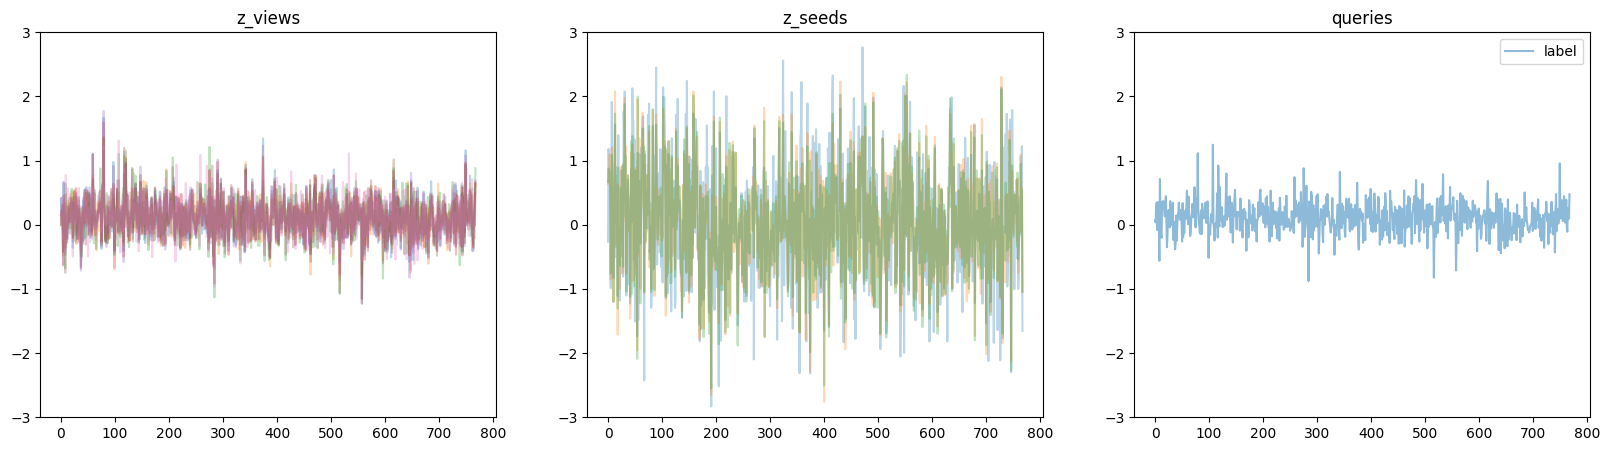

In [64]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
for i in range(n_views):
    plt.plot(z_views[0,i,:], alpha=.3) 
plt.title('z_views')
plt.ylim(-3,3)
print('Z VIEWS')
print(np.corrcoef(z_views[0,:,:].squeeze(0).detach().numpy()))
plt.subplot(1,3,2)
for i in range(k):
    plt.plot(z_seeds[0,i,:], alpha=.3) 
plt.title('z_seeds')
plt.ylim(-3,3)
print('Z SEEDS')
print(np.corrcoef(z_seeds[0,:,:].squeeze(0).detach().numpy()))
plt.subplot(1,3,3)
query_name = ['label', 'pos']
for i in range(k,k+1):
    plt.plot(z_seeds[0,i,:],alpha=.5,label=query_name[i-k])
plt.title('queries')
plt.legend() 
plt.ylim(-3,3)



37
tensor([0.0201, 0.5918]) tensor([690])
[129.   96.5] [131.91809034 182.61157227]


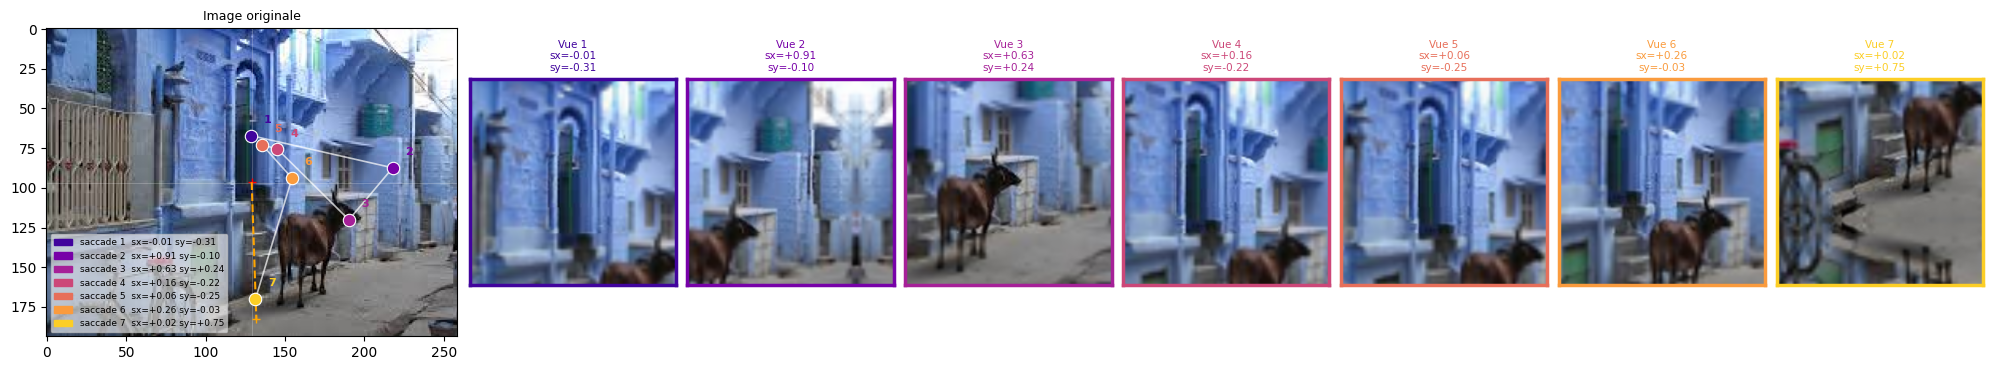

In [63]:
resolution_fov = 512

with torch.no_grad():

    img = Image.open("img/cow.jpg").convert("RGB") # ungulate vs conveyance
    img_np  = np.array(img)                  # (512, 512, 3)  uint8


    zoom = 1.5
    std = 0.5 / zoom
    n_views = 7

    sz = ShiftZoomUplet(zoom=zoom, std=std, n_uplet=n_views)
    #np.random.seed(seed)
    views = sz(img)   # liste de (pil_shifted, sx, sy, zoom)

    W, H   = img.size   
    fix_pts = []
    for _, sx, sy, _ in views:
        #zoomed_ref = min(int(W * zoom), int(H * zoom))
        #cx = zoomed_ref / 2 * (1 + sx / 2)
        #cy = zoomed_ref / 2 * (1 + sy / 2)
        w_zoomed   = int(W * zoom)
        h_zoomed   = int(H * zoom)
        zoomed_ref = min(w_zoomed, h_zoomed)   # petit côté zoomé — référence du shift
        cx = w_zoomed / 2 + zoomed_ref * sx / 2 #zoomed_ref / 2 * (1 + x / 2)   # ∈ [zoomed_ref/4, 3*zoomed_ref/4]
        sy_prim = sy ## !! (no) sign inversion
        cy = h_zoomed / 2 + zoomed_ref * sy_prim / 2 #zoomed_ref / 2 * (1 + y / 2)
        # ramener dans le repère image originale (avant zoom)
        cx_orig = cx / zoom
        cy_orig = cy / zoom
        fix_pts.append((cx_orig, cy_orig))

    fov_tf = val_dataset.fovea_transform
    post_process = val_dataset.post_process

    z_views = []
    mosaics = []
    for pil_shifted, sx, sy, z in views:
        mosaic = fov_tf(pil_shifted)         # PIL 128×128
        mosaic = post_process(mosaic)
        mosaics.append(mosaic)
        #z = teacher_model.forward_features(mosaic.unsqueeze(0))
        z = teacher_model(mosaic.unsqueeze(0))
        z_views.append(z)

    mosaics = torch.stack(mosaics).unsqueeze(0)   # (1, V, 3, 128, 128)
    z_views = torch.stack(z_views, dim=1)
    # foveate_mosaic attend (B, C, H, W) — on boucle sur les vues
    fov_imgs = []
    for v in range(n_views):
        mosaic_v  = mosaics[0, v].unsqueeze(0)    # (1, 3, 128, 128)
        mosaic_d  = denormalize(mosaic_v[0]).unsqueeze(0)  # dénorm avant foveate
        fov_out   = foveate_mosaic(mosaic_d)       # (1, 3, 512, 512)
        fov_np    = fov_out[0].permute(1, 2, 0).numpy()   # (512,512,3)
        fov_np    = np.clip(fov_np, 0, 1)
        fov_imgs.append(fov_np)

    
    if use_synset_embeddings: 
        label = None #'wheeled vehicle' #'ruminant' #'dog' #'carnivore' #'feline' #'placental' #'dog' # 'conveyance' #'ungulate' #'canine' #'carnivore' # 
        if label is not None:
            in_label = torch.tensor(synset_names.index(label), dtype=int).unsqueeze(0)
        else:
            in_label = None
    else:
        label = 'ox' #'bicycle' #'tabby' #'Greater Swiss Mountain dog' # 
        in_label = torch.tensor(find_class_idx(label, classes)[0][0], dtype=int).unsqueeze(0)
        print(find_class_idx(label, classes)[0][0])

    z_seeds = ist_transformer(
                    z_views, in_label
                )
    
    z_pos_in = z_seeds[:, k, :] 
    if abmil_label:
        logits, _ = linear_head(z_seeds[:, :k, :], z_pos_in)

    if abmil_pos:
        pos_out, _ = pos_predictor(z_seeds[:,:k,:], z_pos_in)
    else:
        pos_out = pos_predictor(z_pos_in)
                #print(pos_out[0,:].cpu().detach().numpy())
    preds  = logits.argmax(dim=1)

    pos_out = pos_out.squeeze(0)
    # pos_out[1] = -pos_out[1] # !! (no) sign inversion !!
    print(pos_out, preds)

    orig = np.array((W/2-0.5, H/2-0.5))
    resolution = min(w_zoomed, h_zoomed)
    dest = orig + pos_out.detach().numpy() * resolution/2 
    dest = dest.flatten()
    print(orig, dest)


    # ── 4. Figure ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(4 + 3 * n_views, 4))
    # grille : 1 colonne pour l'original + n_views colonnes pour les vues
    gs  = fig.add_gridspec(1, 1 + n_views, wspace=0.05,
                           width_ratios=[2] + [1] * n_views)

    # ── Panneau gauche : image originale + saccades ──────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img_np) #, origin='lower')

    colors = plt.cm.plasma(np.linspace(0.1, 0.9, n_views))

    xs_plot = [pt[0] for pt in fix_pts]
    ys_plot = [pt[1] for pt in fix_pts]

    # trajectoire
    ax0.plot(xs_plot, ys_plot,
             color='white', linewidth=1.2, alpha=0.7, zorder=2)

    # points de fixation numérotés
    for i, (px, py) in enumerate(fix_pts):
        ax0.scatter(px, py, color=colors[i], s=80, zorder=3,
                    edgecolors='white', linewidths=0.8)
        ax0.text(px + 8, py - 8, str(i + 1),
                 color=colors[i], fontsize=8, fontweight='bold',
                 zorder=4)

    # croix au centre
    ax0.axhline(H / 2, color='white', linewidth=0.5, alpha=0.3)
    ax0.axvline(W / 2, color='white', linewidth=0.5, alpha=0.3)

    ax0.plot(orig[0], orig[1], 'r+')
    ax0.plot(dest[0], dest[1], '+', color='orange')
    ax0.plot((orig[0], dest[0]), (orig[1], dest[1]), '--', color='orange')

    ax0.set_title(f"Image originale", fontsize=9)
    #ax0.axis('off')

    # légende colorbar saccades
    legend_handles = [
        mpatches.Patch(color=colors[i], label=f"saccade {i+1}  "
                       f"sx={views[i][1]:+.2f} sy={views[i][2]:+.2f}")
        for i in range(n_views)
    ]
    ax0.legend(handles=legend_handles, fontsize=6.5,
               loc='lower left', framealpha=0.6)

    # ── Panneaux droits : vues fovéales ──────────────────────────────────
    for v in range(n_views):
        ax = fig.add_subplot(gs[0, 1 + v])
        ax.imshow(fov_imgs[v])
        ax.set_title(f"Vue {v+1}\nsx={views[v][1]:+.2f}\nsy={views[v][2]:+.2f}",
                     fontsize=7.5, color=colors[v])
        # cadre coloré selon la saccade
        for spine in ax.spines.values():
            spine.set_edgecolor(colors[v])
            spine.set_linewidth(2.5)
        ax.set_xticks([])
        ax.set_yticks([])

    #dest_hat = orig + np.array(y_hats[i]) * resolution_fov/2 * 1/zoom

    








232
tensor([0.0179, 0.0758]) tensor([16])
[319.5 239.5] [325.92984104 266.80404854]


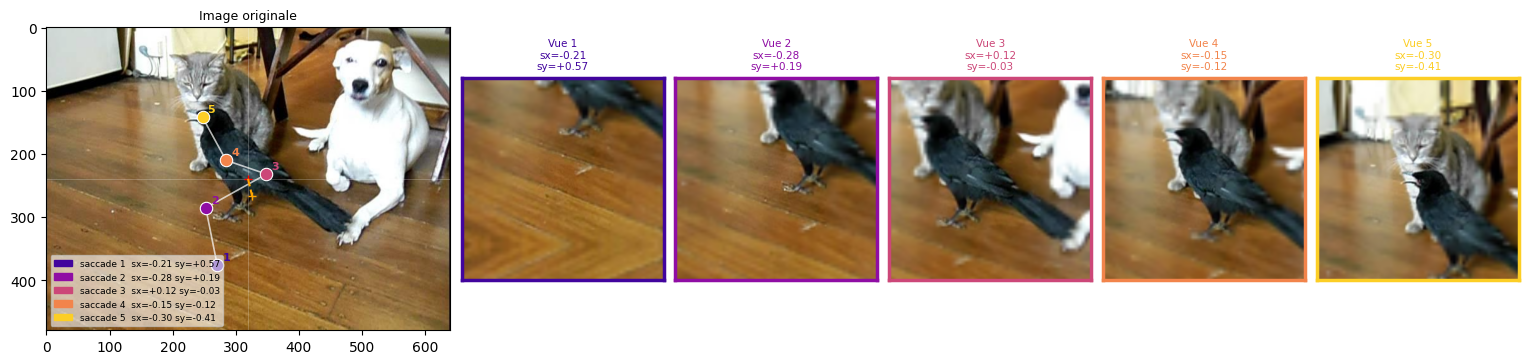

In [84]:
resolution_fov = 512

with torch.no_grad():

    #img = Image.open("img/dog-cat.jpg").convert("RGB")
    img = Image.open("img/cat-bird-dog.jpg").convert("RGB") # ungulate vs conveyance
    img_np  = np.array(img)                  # (512, 512, 3)  uint8


    zoom = 1.5
    std = 0.5 / zoom
    n_views = 5

    sz = ShiftZoomUplet(zoom=zoom, std=std, n_uplet=n_views)
    #np.random.seed(seed)
    views = sz(img)   # liste de (pil_shifted, sx, sy, zoom)

    W, H   = img.size   
    fix_pts = []
    for _, sx, sy, _ in views:
        #zoomed_ref = min(int(W * zoom), int(H * zoom))
        #cx = zoomed_ref / 2 * (1 + sx / 2)
        #cy = zoomed_ref / 2 * (1 + sy / 2)
        w_zoomed   = int(W * zoom)
        h_zoomed   = int(H * zoom)
        zoomed_ref = min(w_zoomed, h_zoomed)   # petit côté zoomé — référence du shift
        cx = w_zoomed / 2 + zoomed_ref * sx / 2 #zoomed_ref / 2 * (1 + x / 2)   # ∈ [zoomed_ref/4, 3*zoomed_ref/4]
        sy_prim = sy ## !! (no) sign inversion
        cy = h_zoomed / 2 + zoomed_ref * sy_prim / 2 #zoomed_ref / 2 * (1 + y / 2)
        # ramener dans le repère image originale (avant zoom)
        cx_orig = cx / zoom
        cy_orig = cy / zoom
        fix_pts.append((cx_orig, cy_orig))

    fov_tf = val_dataset.fovea_transform
    post_process = val_dataset.post_process

    z_views = []
    mosaics = []
    for pil_shifted, sx, sy, z in views:
        mosaic = fov_tf(pil_shifted)         # PIL 128×128
        mosaic = post_process(mosaic)
        mosaics.append(mosaic)
        #z = teacher_model.forward_features(mosaic.unsqueeze(0))
        z = teacher_model(mosaic.unsqueeze(0))
        z_views.append(z)

    mosaics = torch.stack(mosaics).unsqueeze(0)   # (1, V, 3, 128, 128)
    z_views = torch.stack(z_views, dim=1)
    # foveate_mosaic attend (B, C, H, W) — on boucle sur les vues
    fov_imgs = []
    for v in range(n_views):
        mosaic_v  = mosaics[0, v].unsqueeze(0)    # (1, 3, 128, 128)
        mosaic_d  = denormalize(mosaic_v[0]).unsqueeze(0)  # dénorm avant foveate
        fov_out   = foveate_mosaic(mosaic_d)       # (1, 3, 512, 512)
        fov_np    = fov_out[0].permute(1, 2, 0).numpy()   # (512,512,3)
        fov_np    = np.clip(fov_np, 0, 1)
        fov_imgs.append(fov_np)

    
    if use_synset_embeddings: 
        label = None #'dog' #'bird' #'ruminant' #'carnivore' #'ungulate' #'canine' #'feline' # 'dog'
        if label is not None:
            in_label = torch.tensor(synset_names.index(label), dtype=int).unsqueeze(0)
        else:
            in_label = None
    else:
        label = 'Border Collie' #'tabby' #'Greater Swiss Mountain dog' # 
        in_label = torch.tensor(find_class_idx(label, classes)[0][0], dtype=int).unsqueeze(0)
        print(find_class_idx(label, classes)[0][0])

    z_seeds = ist_transformer(
                    z_views, in_label
                )
    
    z_pos_in = z_seeds[:, k, :] 
    if abmil_label:
        logits, _ = linear_head(z_seeds[:, :k, :], z_pos_in)

    if abmil_pos:
        pos_out, _ = pos_predictor(z_seeds[:,:k,:], z_pos_in)
    else:
        pos_out = pos_predictor(z_pos_in)
                #print(pos_out[0,:].cpu().detach().numpy())
    preds  = logits.argmax(dim=1)

    pos_out = pos_out.squeeze(0)
    # pos_out[1] = -pos_out[1] # !! (no) sign inversion !!
    print(pos_out, preds)

    orig = np.array((W/2-0.5, H/2-0.5))
    resolution = min(w_zoomed, h_zoomed)
    dest = orig + pos_out.detach().numpy() * resolution/2 
    dest = dest.flatten()
    print(orig, dest)


    # ── 4. Figure ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(4 + 3 * n_views, 4))
    # grille : 1 colonne pour l'original + n_views colonnes pour les vues
    gs  = fig.add_gridspec(1, 1 + n_views, wspace=0.05,
                           width_ratios=[2] + [1] * n_views)

    # ── Panneau gauche : image originale + saccades ──────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img_np) #, origin='lower')

    colors = plt.cm.plasma(np.linspace(0.1, 0.9, n_views))

    xs_plot = [pt[0] for pt in fix_pts]
    ys_plot = [pt[1] for pt in fix_pts]

    # trajectoire
    ax0.plot(xs_plot, ys_plot,
             color='white', linewidth=1.2, alpha=0.7, zorder=2)

    # points de fixation numérotés
    for i, (px, py) in enumerate(fix_pts):
        ax0.scatter(px, py, color=colors[i], s=80, zorder=3,
                    edgecolors='white', linewidths=0.8)
        ax0.text(px + 8, py - 8, str(i + 1),
                 color=colors[i], fontsize=8, fontweight='bold',
                 zorder=4)

    # croix au centre
    ax0.axhline(H / 2, color='white', linewidth=0.5, alpha=0.3)
    ax0.axvline(W / 2, color='white', linewidth=0.5, alpha=0.3)

    ax0.plot(orig[0], orig[1], 'r+')
    ax0.plot(dest[0], dest[1], '+', color='orange')
    ax0.plot((orig[0], dest[0]), (orig[1], dest[1]), '--', color='orange')

    ax0.set_title(f"Image originale", fontsize=9)
    #ax0.axis('off')

    # légende colorbar saccades
    legend_handles = [
        mpatches.Patch(color=colors[i], label=f"saccade {i+1}  "
                       f"sx={views[i][1]:+.2f} sy={views[i][2]:+.2f}")
        for i in range(n_views)
    ]
    ax0.legend(handles=legend_handles, fontsize=6.5,
               loc='lower left', framealpha=0.6)

    # ── Panneaux droits : vues fovéales ──────────────────────────────────
    for v in range(n_views):
        ax = fig.add_subplot(gs[0, 1 + v])
        ax.imshow(fov_imgs[v])
        ax.set_title(f"Vue {v+1}\nsx={views[v][1]:+.2f}\nsy={views[v][2]:+.2f}",
                     fontsize=7.5, color=colors[v])
        # cadre coloré selon la saccade
        for spine in ax.spines.values():
            spine.set_edgecolor(colors[v])
            spine.set_linewidth(2.5)
        ax.set_xticks([])
        ax.set_yticks([])

    #dest_hat = orig + np.array(y_hats[i]) * resolution_fov/2 * 1/zoom

    








black stork
Prediction black stork
tensor([-0.3230, -0.3806]) tensor([128])
[249.5 187. ] [158.73588562  80.03806305]


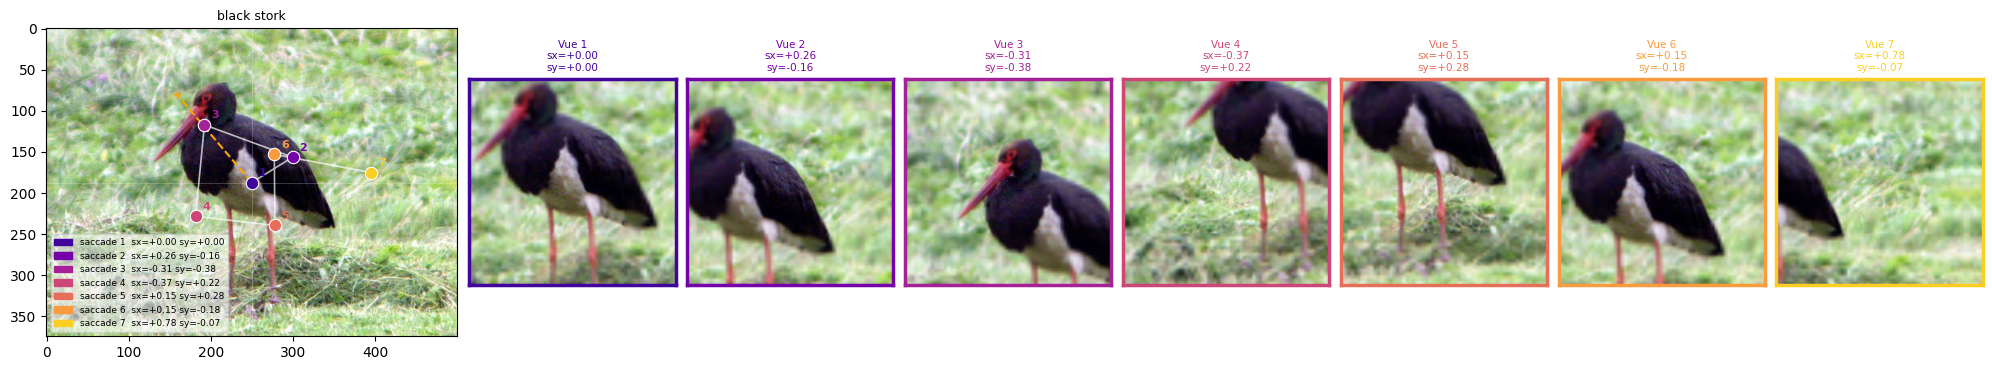

In [68]:
resolution_fov = 512

with torch.no_grad():

    #img = Image.open("img/dog-cat.jpg").convert("RGB")
    #img = Image.open("img/lion-and-gazelle.jpg").convert("RGB") # ungulate vs conveyance
    # 13606 : coyote
    # 17851 : martre
    # 2445 : komodo dragon
    # 6414 : black stork
    # 7263 : king penguin
    # 7512 : sea lion
    # 9521 : silean terier
    # 12877 : great pyrenees
    # 17278 : ox
    # 37150 : printer
    # 33668 : mouse
    # 22394 : binocular
    # 33671 : !! mouse / coffee cup (ambigu)
    # 9570 : ! airedale (off-center)
    # 304 : !!! sting ray (out of sight)
    # 33145 : !! modem (ambiguous)
    # 48759 : !!! lakeside (with cygns)
    # 46980 : !! courgette (ambigu : tomates, pommes,...)
    random_idx = random.randint(0, len(val_dataset_raw) - 1)
    random_idx = 6414 #304 #33671 #17851 #13606 #2445 #
    img, label = val_dataset_raw[random_idx]
    class_name = classes[label]
    print(classes[label])
    img_np  = np.array(img)                  # (512, 512, 3)  uint8

    zoom = 1.5
    std = 0.5 / zoom
    n_views = 7

    sz = ShiftZoomUplet(zoom=zoom, std=std, n_uplet=n_views, start_center=True)
    #np.random.seed(seed)
    views = sz(img)   # liste de (pil_shifted, sx, sy, zoom)

    W, H   = img.size   
    fix_pts = []
    for _, sx, sy, _ in views:
        #zoomed_ref = min(int(W * zoom), int(H * zoom))
        #cx = zoomed_ref / 2 * (1 + sx / 2)
        #cy = zoomed_ref / 2 * (1 + sy / 2)
        w_zoomed   = int(W * zoom)
        h_zoomed   = int(H * zoom)
        zoomed_ref = min(w_zoomed, h_zoomed)   # petit côté zoomé — référence du shift
        cx = w_zoomed / 2 + zoomed_ref * sx / 2 #zoomed_ref / 2 * (1 + x / 2)   # ∈ [zoomed_ref/4, 3*zoomed_ref/4]
        sy_prim = sy ## !! (no) sign inversion
        cy = h_zoomed / 2 + zoomed_ref * sy_prim / 2 #zoomed_ref / 2 * (1 + y / 2)
        # ramener dans le repère image originale (avant zoom)
        cx_orig = cx / zoom
        cy_orig = cy / zoom
        fix_pts.append((cx_orig, cy_orig))

    fov_tf = val_dataset.fovea_transform
    post_process = val_dataset.post_process

    z_views = []
    mosaics = []
    for pil_shifted, sx, sy, z in views:
        mosaic = fov_tf(pil_shifted)         # PIL 128×128
        mosaic = post_process(mosaic)
        mosaics.append(mosaic)
        #z = teacher_model.forward_features(mosaic.unsqueeze(0))
        z = teacher_model(mosaic.unsqueeze(0))
        z_views.append(z)

    mosaics = torch.stack(mosaics).unsqueeze(0)   # (1, V, 3, 128, 128)
    z_views = torch.stack(z_views, dim=1)
    # foveate_mosaic attend (B, C, H, W) — on boucle sur les vues
    fov_imgs = []
    for v in range(n_views):
        mosaic_v  = mosaics[0, v].unsqueeze(0)    # (1, 3, 128, 128)
        mosaic_d  = denormalize(mosaic_v[0]).unsqueeze(0)  # dénorm avant foveate
        fov_out   = foveate_mosaic(mosaic_d)       # (1, 3, 512, 512)
        fov_np    = fov_out[0].permute(1, 2, 0).numpy()   # (512,512,3)
        fov_np    = np.clip(fov_np, 0, 1)
        fov_imgs.append(fov_np)

    
    if use_synset_embeddings: 
        label = None #'Komodo dragon' #'ungulate' #'carnivore' #'bovid' #'canine' #'carnivore' #'feline' # 'dog'
        if label is not None:
            in_label = torch.tensor(synset_names.index(label), dtype=int).unsqueeze(0)
        else:
            in_label = None
    else:
        label = None #'coyote' #'lion' #'Border Collie' #'tabby' #'Greater Swiss Mountain dog' # 
        if label is not None:
            in_label = torch.tensor(find_class_idx(label, classes)[0][0], dtype=int).unsqueeze(0)
        else:
            in_label = None
        

    z_seeds = ist_transformer(
                    z_views, in_label
                )
    
    z_pos_in = z_seeds[:, k, :] 
    if abmil_label:
        logits, _ = linear_head(z_seeds[:, :k, :], z_pos_in)

    if abmil_pos:
        pos_out, _ = pos_predictor(z_seeds[:,:k,:], z_pos_in)
    else:
        pos_out = pos_predictor(z_pos_in)
                #print(pos_out[0,:].cpu().detach().numpy())
    preds  = logits.argmax(dim=1)
    print('Prediction', classes[preds])

    pos_out = pos_out.squeeze(0)
    # pos_out[1] = -pos_out[1] # !! (no) sign inversion !!
    print(pos_out, preds)

    orig = np.array((W/2-0.5, H/2-0.5))
    resolution = min(w_zoomed, h_zoomed)
    dest = orig + pos_out.detach().numpy() * resolution/2 
    dest = dest.flatten()
    print(orig, dest)


    # ── 4. Figure ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(4 + 3 * n_views, 4))
    # grille : 1 colonne pour l'original + n_views colonnes pour les vues
    gs  = fig.add_gridspec(1, 1 + n_views, wspace=0.05,
                           width_ratios=[2] + [1] * n_views)

    # ── Panneau gauche : image originale + saccades ──────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img_np) #, origin='lower')

    colors = plt.cm.plasma(np.linspace(0.1, 0.9, n_views))

    xs_plot = [pt[0] for pt in fix_pts]
    ys_plot = [pt[1] for pt in fix_pts]

    # trajectoire
    ax0.plot(xs_plot, ys_plot,
             color='white', linewidth=1.2, alpha=0.7, zorder=2)

    # points de fixation numérotés
    for i, (px, py) in enumerate(fix_pts):
        ax0.scatter(px, py, color=colors[i], s=80, zorder=3,
                    edgecolors='white', linewidths=0.8)
        ax0.text(px + 8, py - 8, str(i + 1),
                 color=colors[i], fontsize=8, fontweight='bold',
                 zorder=4)

    # croix au centre
    ax0.axhline(H / 2, color='white', linewidth=0.5, alpha=0.3)
    ax0.axvline(W / 2, color='white', linewidth=0.5, alpha=0.3)

    ax0.plot(orig[0], orig[1], 'r+')
    ax0.plot(dest[0], dest[1], '+', color='orange')
    ax0.plot((orig[0], dest[0]), (orig[1], dest[1]), '--', color='orange')

    ax0.set_title(f"{class_name}", fontsize=9)
    #ax0.axis('off')

    # légende colorbar saccades
    legend_handles = [
        mpatches.Patch(color=colors[i], label=f"saccade {i+1}  "
                       f"sx={views[i][1]:+.2f} sy={views[i][2]:+.2f}")
        for i in range(n_views)
    ]
    ax0.legend(handles=legend_handles, fontsize=6.5,
               loc='lower left', framealpha=0.6)

    # ── Panneaux droits : vues fovéales ──────────────────────────────────
    for v in range(n_views):
        ax = fig.add_subplot(gs[0, 1 + v])
        ax.imshow(fov_imgs[v])
        ax.set_title(f"Vue {v+1}\nsx={views[v][1]:+.2f}\nsy={views[v][2]:+.2f}",
                     fontsize=7.5, color=colors[v])
        # cadre coloré selon la saccade
        for spine in ax.spines.values():
            spine.set_edgecolor(colors[v])
            spine.set_linewidth(2.5)
        ax.set_xticks([])
        ax.set_yticks([])

    #dest_hat = orig + np.array(y_hats[i]) * resolution_fov/2 * 1/zoom

    








In [244]:
random_idx

46980

Z VIEWS
[[1.         0.80646457 0.96432432 0.32944364 0.89567146 0.45900728
  0.67566724]
 [0.80646457 1.         0.75643613 0.52576663 0.67655854 0.7077135
  0.56939842]
 [0.96432432 0.75643613 1.         0.28792349 0.93104095 0.41545674
  0.66194639]
 [0.32944364 0.52576663 0.28792349 1.         0.2130703  0.6802091
  0.34876462]
 [0.89567146 0.67655854 0.93104095 0.2130703  1.         0.36351894
  0.54550694]
 [0.45900728 0.7077135  0.41545674 0.6802091  0.36351894 1.
  0.30176519]
 [0.67566724 0.56939842 0.66194639 0.34876462 0.54550694 0.30176519
  1.        ]]
Z SEEDS
[[1.         0.82413753 0.88022363 0.03417408]
 [0.82413753 1.         0.96326401 0.02732774]
 [0.88022363 0.96326401 1.         0.01718995]
 [0.03417408 0.02732774 0.01718995 1.        ]]


(-3.0, 3.0)

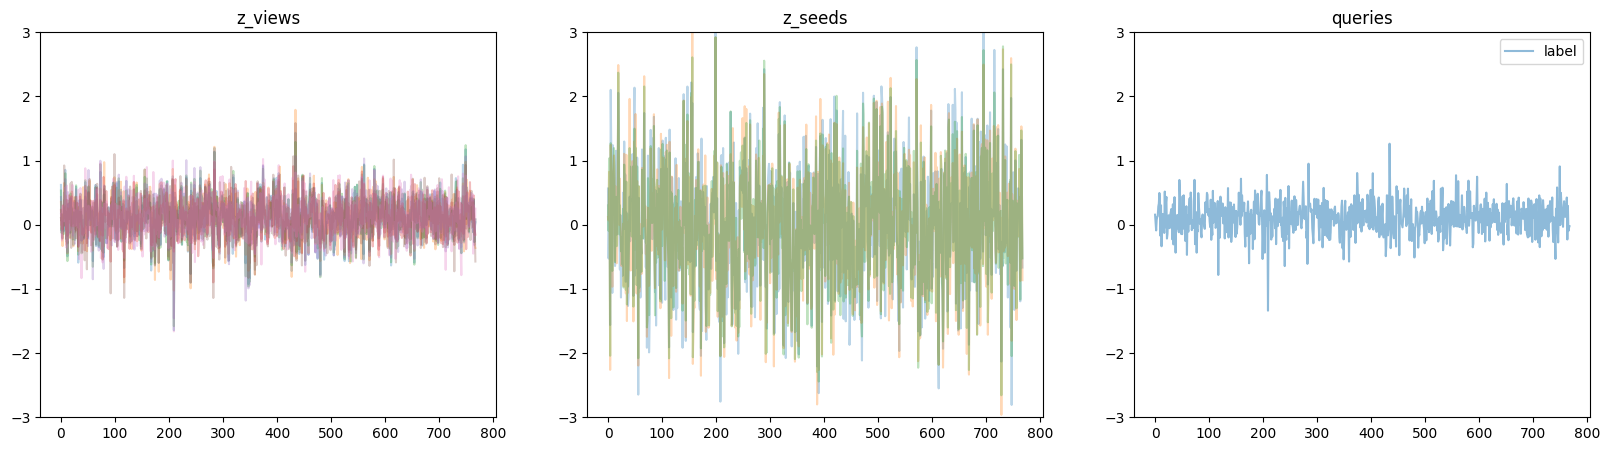

In [200]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
for i in range(n_views):
    plt.plot(z_views[0,i,:], alpha=.3) 
plt.title('z_views')
plt.ylim(-3,3)
print('Z VIEWS')
print(np.corrcoef(z_views[0,:,:].squeeze(0).detach().numpy()))
plt.subplot(1,3,2)
for i in range(k):
    plt.plot(z_seeds[0,i,:], alpha=.3) 
plt.title('z_seeds')
plt.ylim(-3,3)
print('Z SEEDS')
print(np.corrcoef(z_seeds[0,:,:].squeeze(0).detach().numpy()))
plt.subplot(1,3,3)
query_name = ['label', 'pos']
for i in range(k,k+1):
    plt.plot(z_seeds[0,i,:],alpha=.5,label=query_name[i-k])
plt.title('queries')
plt.legend() 
plt.ylim(-3,3)



In [ ]:
orig

array([287.5, 197. ])